# Setting up the mesh and coordinates of the Nodes

In [ ]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time
from scipy.optimize import fsolve
import pandas as pd
from scipy.interpolate import interp1d
from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import NearestNDInterpolator
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
from scipy.linalg import eigvalsh
from scipy.linalg import lu_factor, lu_solve
from scipy.fft import rfft, rfftfreq

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

Beam length             : 11000.000 m
Number of elements      : 1760
Number of nodes         : 1761
Actual element length   : 6.250 m
[[   0    1]
 [   1    2]
 [   2    3]
 ...
 [1757 1758]
 [1758 1759]
 [1759 1760]]


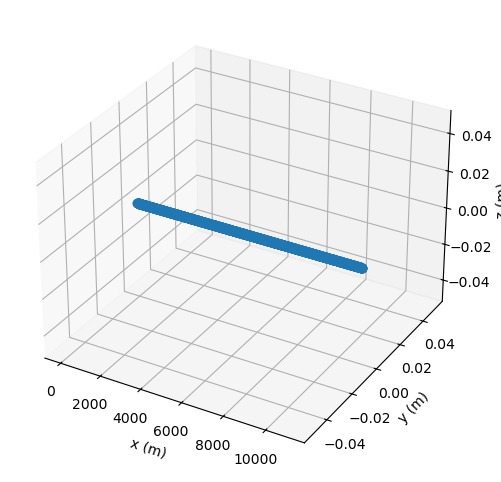

In [ ]:
L = 11000.0
Le = 6.25 

nEle = max(1, int(round(L / Le)))
actual_Le = L / nEle
nNodes = nEle + 1

x = np.linspace(0, L, nNodes)
y = np.zeros_like(x)
z = np.zeros_like(x)


elements = np.column_stack([np.arange(nEle), np.arange(1, nEle + 1)])

print(f"Beam length             : {L:.3f} m")
print(f"Number of elements      : {nEle}")
print(f"Number of nodes         : {nNodes}")
print(f"Actual element length   : {actual_Le:.3f} m")
print(elements)

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot(x, y, z, "-o", lw=2)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
plt.grid(True)
plt.show()

## Define beam properties

In [ ]:
E = 39e9                                  # Pa, Young's modulus of reinforced concrete
G = 16.3e9                                 # Pa, shear modulus of reinforced concrete
h_out = 6                                  # m, outer diameter of the connector
h_in = 5                                  # m, inner diameter of the connector
w_out = 5.5                                # m, outer width of the connector
w_in = 4.5                                # m, inner width of the connector
t= 0.5
connector_spacing = 250                               # m, spacing between connectors along the beam
hm = 6-t
bm = 5.5-t
Am = hm*bm
pm = 2*(hm+bm)                                                  # m, perimeter of the connector cross-section
Concrete_density = 2600                                         # kg/m3, density of reinforced concrete
TunArea = 6*5.5 - 5*4.5                                         # m2, cross-sectional area of the connector
connector_GJ = G*(2*t**2 * bm**2 * hm**2/(bm+hm))                                 # [N.m2]
connector_Im = 2600* (bm**2 + hm**2)**2 * bm*hm*t / 144         #[kg.m] (Volgens mij hoort dit niet zo)
connector_m =  (TunArea) *2600                                  # [kg/m]
connector_EIy = 1/12 * (w_out**3*h_out - w_in**3*h_in) * E      # [N.m2]
connector_EIz = 1/12 * (w_out*h_out**3 - w_in*h_in**3) * E      # [N.m2]
connector_EA = (6 * 5.5 - 5 * 4.5) * E     # [N]
GJ_eff_connector = connector_GJ / connector_spacing
Im_eff_connector = connector_Im / connector_spacing
EIy_eff_connector = connector_EIy / connector_spacing
EIz_eff_connector = connector_EIz / connector_spacing
EA_eff_connector = connector_EA / connector_spacing
m_eff_connector = connector_m / connector_spacing
Beam_GJ = 9.5e12 * 2 +  GJ_eff_connector             # [N.m2]
Beam_Im = 1.5e6 * 2 +  Im_eff_connector                     #[kg.m]
Beam_m = 1.1e5 * 2 +  m_eff_connector                 # [kg/m]
Beam_EIy = 141193e9 * 2 +  EIy_eff_connector              # [N.m2]
Beam_EIz = 141193e9 * 2 +  EIz_eff_connector               # [N.m2]
Beam_EA = 15.5*39e9 * 2 +  EA_eff_connector              # [N]

# Mesh setup


In [ ]:
NodeC = [[x, y, z] for x, y, z in zip(x, y, z)]
nNodes = len(NodeC)
Ele_tunnel = [[n1, n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im] for n1 in range(0, nNodes - 1)]
escape_spacing = 250.0
NodeArr = np.array(NodeC, dtype=float)

print(f"Total nodes : {nNodes}")
print(NodeC)
print(NodeArr)
print(len(NodeArr))

Total nodes : 1761
[[np.float64(0.0), np.float64(0.0), np.float64(0.0)], [np.float64(6.25), np.float64(0.0), np.float64(0.0)], [np.float64(12.5), np.float64(0.0), np.float64(0.0)], [np.float64(18.75), np.float64(0.0), np.float64(0.0)], [np.float64(25.0), np.float64(0.0), np.float64(0.0)], [np.float64(31.25), np.float64(0.0), np.float64(0.0)], [np.float64(37.5), np.float64(0.0), np.float64(0.0)], [np.float64(43.75), np.float64(0.0), np.float64(0.0)], [np.float64(50.0), np.float64(0.0), np.float64(0.0)], [np.float64(56.25), np.float64(0.0), np.float64(0.0)], [np.float64(62.5), np.float64(0.0), np.float64(0.0)], [np.float64(68.75), np.float64(0.0), np.float64(0.0)], [np.float64(75.0), np.float64(0.0), np.float64(0.0)], [np.float64(81.25), np.float64(0.0), np.float64(0.0)], [np.float64(87.5), np.float64(0.0), np.float64(0.0)], [np.float64(93.75), np.float64(0.0), np.float64(0.0)], [np.float64(100.0), np.float64(0.0), np.float64(0.0)], [np.float64(106.25), np.float64(0.0), np.float64(0.0)],

# Add mooring 

In [ ]:
mooring_spacing = 25.0

s = np.linspace(0, L, nNodes)
target_spacing = np.arange(0.0, L + 0.5 * mooring_spacing, mooring_spacing)

mooring_nodes = np.unique([int(np.argmin(np.abs(s - target))) for target in target_spacing])

print("Mooring target positions:", target_spacing)
print("Mooring node indices:", mooring_nodes)
print("Mooring node positions:", s[mooring_nodes])


Mooring target positions: [    0.    25.    50.    75.   100.   125.   150.   175.   200.   225.
   250.   275.   300.   325.   350.   375.   400.   425.   450.   475.
   500.   525.   550.   575.   600.   625.   650.   675.   700.   725.
   750.   775.   800.   825.   850.   875.   900.   925.   950.   975.
  1000.  1025.  1050.  1075.  1100.  1125.  1150.  1175.  1200.  1225.
  1250.  1275.  1300.  1325.  1350.  1375.  1400.  1425.  1450.  1475.
  1500.  1525.  1550.  1575.  1600.  1625.  1650.  1675.  1700.  1725.
  1750.  1775.  1800.  1825.  1850.  1875.  1900.  1925.  1950.  1975.
  2000.  2025.  2050.  2075.  2100.  2125.  2150.  2175.  2200.  2225.
  2250.  2275.  2300.  2325.  2350.  2375.  2400.  2425.  2450.  2475.
  2500.  2525.  2550.  2575.  2600.  2625.  2650.  2675.  2700.  2725.
  2750.  2775.  2800.  2825.  2850.  2875.  2900.  2925.  2950.  2975.
  3000.  3025.  3050.  3075.  3100.  3125.  3150.  3175.  3200.  3225.
  3250.  3275.  3300.  3325.  3350.  3375.  3400.  

# Global Matrixes

In [ ]:
LDOF = 6
nDof = LDOF*nNodes 
K = np.zeros(nDof*nDof)
M = np.zeros(nDof*nDof)
Q = np.zeros(nDof*nDof)

from BeamMatrices import Beam3DMatrices

for iEle in range(0, nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele_tunnel[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    
    n1dof = LDOF*n1 + np.arange(0,LDOF)
    n2dof = LDOF*n2 + np.arange(0,LDOF)    
    
    Me, Ke, Qe = Beam3DMatrices(m, EA, EIy, EIz, GJ, Im, (NodeC[n1], NodeC[n2]) )
    
    indexes = np.append(n1dof, n2dof)
    for i in range(0, 2*LDOF):
        for j in range(0, 2*LDOF):
            ij = indexes[i]*nDof + indexes[j]
            #print(ij)
            M[ij] = M[ij] + Me[i,j]
            K[ij] = K[ij] + Ke[i,j]
            Q[ij] = Q[ij] + Qe[i,j]

M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))

M_lumped = np.zeros_like(M)

for iEle in range(nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele_tunnel[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))

    L_ele = np.linalg.norm(np.array(NodeC[n2]) - np.array(NodeC[n1]))

    M_node = m * L_ele / 2
    Jx_node = Beam_Im * L_ele / 2
    J_bend_y = Beam_EIy * L_ele / 2
    J_bend_z = Beam_EIz * L_ele / 2

    for node in [n1, n2]:
        i = node * LDOF

        M_lumped[i + 0, i + 0] += M_node
        M_lumped[i + 1, i + 1] += M_node
        M_lumped[i + 2, i + 2] += M_node
        M_lumped[i + 3, i + 3] += Jx_node
        M_lumped[i + 4, i + 4] += J_bend_y
        M_lumped[i + 5, i + 5] += J_bend_z

M = M_lumped


# Add Added-Mass, Mooring stiffness and Added Damping

In [ ]:
rho_w = 1027.0     
Cm = 1.0           
D_outer = 12.7      

A_disp = np.pi * D_outer**2 / 4

m_added = rho_w * Cm * A_disp
M_added = m_added * Q
M = M + M_added

print("Added mass per meter:", round(m_added, 2), "kg/m")
print("Structural mass per meter:", round(Beam_m, 2), "kg/m")
print("Added/structural mass ratio:", round(m_added / Beam_m, 2))


n_stiff = 360
half_n = n_stiff // 2

k_start_v = 45
k_start_h = 161

k_mid_v = 60
k_mid_h = 396

k_end_v = 81
k_end_h = 843

k_v = np.linspace(k_start_v, k_mid_v, half_n + 1)
k_h = np.linspace(k_start_h, k_mid_h, half_n + 1)


print(k_v)
print(k_h)

Added mass per meter: 129843.79 kg/m
Structural mass per meter: 220109.2 kg/m
Added/structural mass ratio: 0.59
[45.         45.08333333 45.16666667 45.25       45.33333333 45.41666667
 45.5        45.58333333 45.66666667 45.75       45.83333333 45.91666667
 46.         46.08333333 46.16666667 46.25       46.33333333 46.41666667
 46.5        46.58333333 46.66666667 46.75       46.83333333 46.91666667
 47.         47.08333333 47.16666667 47.25       47.33333333 47.41666667
 47.5        47.58333333 47.66666667 47.75       47.83333333 47.91666667
 48.         48.08333333 48.16666667 48.25       48.33333333 48.41666667
 48.5        48.58333333 48.66666667 48.75       48.83333333 48.91666667
 49.         49.08333333 49.16666667 49.25       49.33333333 49.41666667
 49.5        49.58333333 49.66666667 49.75       49.83333333 49.91666667
 50.         50.08333333 50.16666667 50.25       50.33333333 50.41666667
 50.5        50.58333333 50.66666667 50.75       50.83333333 50.91666667
 51.        

Sum of stiffness matrix before applying boundary conditions: 1.908528857664e+18


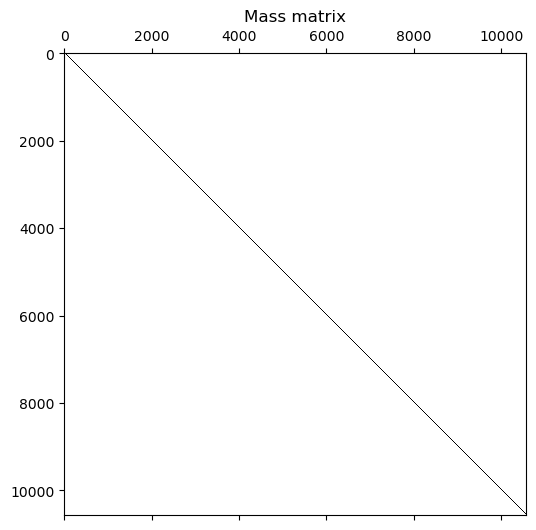

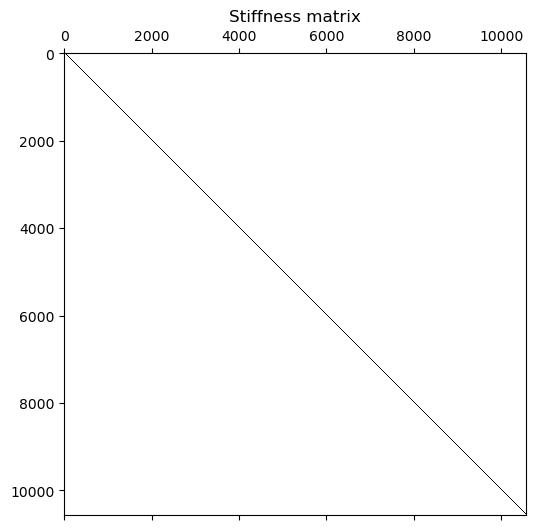

In [8]:
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
K_sum_before = np.sum(K)
print("Sum of stiffness matrix before applying boundary conditions:", K_sum_before)
pass

# Matrixes after adding stiffness and Mass

In [ ]:
K_before = K.copy()

cat_i = 0
added = 0.0

def AddMooringSpringHV(K, node_id, kh, kv, LDOF=6):
    i = int(node_id) * LDOF
    K[i + 1, i + 1] += kh   # y-direction, horizontal transverse
    K[i + 2, i + 2] += kv   # z-direction, vertical
    return K

for node in mooring_nodes:
    s_moor = s[node]

    if s_moor < 1000:
        kh = 120e3
        kv = 85e3

    elif 1000 <= s_moor < 10000:
        idx = min(cat_i, len(k_h) - 1)
        kh = k_h[idx] * 1e2
        kv = k_v[idx] * 1e3
        cat_i += 1

    else:
        kh = 200e3
        kv = 85e3

    K = AddMooringSpringHV(K, node, kh, kv, LDOF=LDOF)
    added += kh + kv

K_after = K.copy()

print("Expected added stiffness:", added)
print("Actual added diagonal stiffness:", np.sum(np.diag(K_after - K_before)))

for node in mooring_nodes:
    dof_y = node * LDOF + 1
    dof_z = node * LDOF + 2

    print(f"Node {node}: " f"ΔK_uy = {K_after[dof_y, dof_y] - K_before[dof_y, dof_y]:.3e}, " f"ΔK_uz = {K_after[dof_z, dof_z] - K_before[dof_z, dof_z]:.3e}")

for i in range(min(10, nNodes)):
    print( M[i*LDOF+3, i*LDOF+3], M[i*LDOF+4, i*LDOF+4],  M[i*LDOF+5, i*LDOF+5])

Expected added stiffness: 52256750.0
Actual added diagonal stiffness: 52256750.0
Node 0: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 4: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 8: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 12: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 16: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 20: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 24: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 28: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 32: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 36: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 40: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 44: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 48: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 52: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 56: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 60: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 64: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 68: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 72: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
Node 76: ΔK_uy = 1.200e+05, ΔK_uz = 8.500e+04
No

In [ ]:
NodesClamp = (0, nNodes-1)
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp: DofsP = np.append(DofsP, n0*LDOF + np.array([0,1,2]))

DofsF = np.arange(0, nDof)
DofsF = np.delete(DofsF, DofsP) 

print(DofsP)
print(DofsF)

def AddRotationalSpring(K, node_id, krx, kry, krz, LDOF=6):

    i = node_id * LDOF

    K[i+3, i+3] += krx
    K[i+4, i+4] += kry
    K[i+5, i+5] += krz

    return K


# Assumption made for 100 and 10 times stiffness at BC!

krx_end = Beam_Im * 100  
kry_end = Beam_EIy * 10  
krz_end = Beam_EIz * 10 

for node in NodesClamp:
    K = AddRotationalSpring(K, node, krx_end, kry_end, krz_end, LDOF=LDOF)

M_FF = M[np.ix_(DofsF, DofsF)]
K_FF = K[np.ix_(DofsF, DofsF)]
Q_FF = Q[np.ix_(DofsF, DofsF)]

print("K shape:", K.shape)
print("K_FF shape:", K_FF.shape)
print("Number of prescribed DOFs:", len(DofsP))
print("Number of free DOFs:", len(DofsF))
pass

[    0     1     2 10560 10561 10562]
[    3     4     5 ... 10563 10564 10565]
K shape: (10566, 10566)
K_FF shape: (10560, 10560)
Number of prescribed DOFs: 6
Number of free DOFs: 10560


# Eigen frequencies and Modal Shapes

In [ ]:
m_eigs = eigvalsh(M_FF)
print("Smallest eigenvalues of M_FF:")
print(m_eigs[:20])
print("Number <= 0:", np.sum(m_eigs <= 0))

bad_modes = np.where(m_eigs <= 0)[0]

Smallest eigenvalues of M_FF:
[1646190.9360393  1646192.2894385  1646194.42776224 1646197.42726042
 1646201.44883101 1646206.10860221 1646211.69693229 1646218.09516803
 1646225.44789505 1646233.62266732 1646242.67210507 1646252.59016661
 1646263.46089896 1646275.03894532 1646287.5288396  1646300.87545642
 1646315.12218027 1646330.1946456  1646346.13846896 1646362.90054698]
Number <= 0: 0


In [ ]:
Me, _, _ = Beam3DMatrices(Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im, (NodeC[0], NodeC[1]))
eig = np.linalg.eigvalsh(Me)
print(np.min(eig))
print(eig)

-228921.61819613999
[-2.28921618e+05  1.99049583e+04  6.77395972e+04  8.96981706e+04
  2.29280417e+05  4.42136024e+05  6.87841250e+05  9.32799793e+05
  1.25193251e+06  1.51572828e+06  6.88536282e+11  2.06560885e+12]


In [ ]:
n_modes = 500
w2, vr = eigh(K_FF, M_FF)
w2 = w2[:n_modes]
vr = vr[:, :n_modes]
w = np.sqrt(np.maximum(w2, 0))
f = w / (2*np.pi)

print(f)

[0.00034112 0.00034761 0.00037996 0.00038652 0.00038905 0.00039055
 0.00041899 0.00042155 0.00043071 0.00044396 0.00046188 0.00047479
 0.00049744 0.00051347 0.00052557 0.00053003 0.0005731  0.00058075
 0.00058211 0.00060251 0.00064254 0.00065456 0.00065951 0.00068303
 0.00071667 0.0007374  0.00074078 0.0007573  0.00079372 0.00081014
 0.00082403 0.00082458 0.00087552 0.00087773 0.00091155 0.00091219
 0.00096159 0.00096191 0.00099968 0.00100148 0.00104989 0.00105004
 0.00108791 0.00109117 0.00113929 0.00113939 0.00117379 0.00118105
 0.0012289  0.00122942 0.00124599 0.0012709  0.00129697 0.00131977
 0.00131986 0.0013604  0.00137274 0.00141018 0.00141029 0.00144862
 0.00145978 0.00150079 0.00150088 0.00153054 0.00154906 0.00158599
 0.00159151 0.00159157 0.00163901 0.00164808 0.00168216 0.00168219
 0.00172923 0.00173249 0.00177281 0.00177292 0.00181961 0.00182126
 0.00186353 0.00186362 0.0019101  0.00191109 0.00195428 0.00195434
 0.00200066 0.00200133 0.00204505 0.00204509 0.00209129 0.0020

In [ ]:
Phi = np.zeros((nDof, n_modes))

for i in range(n_modes):
    Phi[DofsF, i] = vr[:, i]


def plot_mode(mode_id, scale=1.0, direction="z"):
    phi = Phi[:, mode_id]
    ux = phi[0::LDOF]
    uy = phi[1::LDOF]
    uz = phi[2::LDOF]

    if direction == "y":
        deformation = uy
        ylabel = "y displacement mode shape"
    elif direction == "z":
        deformation = uz
        ylabel = "z displacement mode shape"
    else:
        raise ValueError("direction must be 'y' or 'z'")

    deformation = deformation / np.max(np.abs(deformation))

    plt.figure()
    plt.plot(s, deformation, "-o")
    plt.xlabel("Beam coordinate s [m]")
    plt.ylabel(ylabel)
    plt.title(f"Mode {mode_id + 1}, f = {f[mode_id]:.4f} Hz")
    plt.grid(True)
    plt.show()



def plot_mode_3d(mode_id, scale=5.0):
    phi = Phi[:, mode_id]

    ux = phi[0::LDOF]
    uy = phi[1::LDOF]
    uz = phi[2::LDOF]

    max_disp = max(
        np.max(np.abs(ux)),
        np.max(np.abs(uy)),
        np.max(np.abs(uz))
    )

    ux = ux / max_disp
    uy = uy / max_disp
    uz = uz / max_disp

    x_def = x + scale * ux
    y_def = y + scale * uy
    z_def = z + scale * uz

    fig = plt.figure()
    ax = plt.axes(projection="3d")

    ax.plot(x, y, z, "k--", label="undeformed")
    ax.plot(x_def, y_def, z_def, "-o", label="mode shape")

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(f"Mode {mode_id + 1}, f = {f[mode_id]:.4f} Hz")
    ax.legend()
    plt.show()


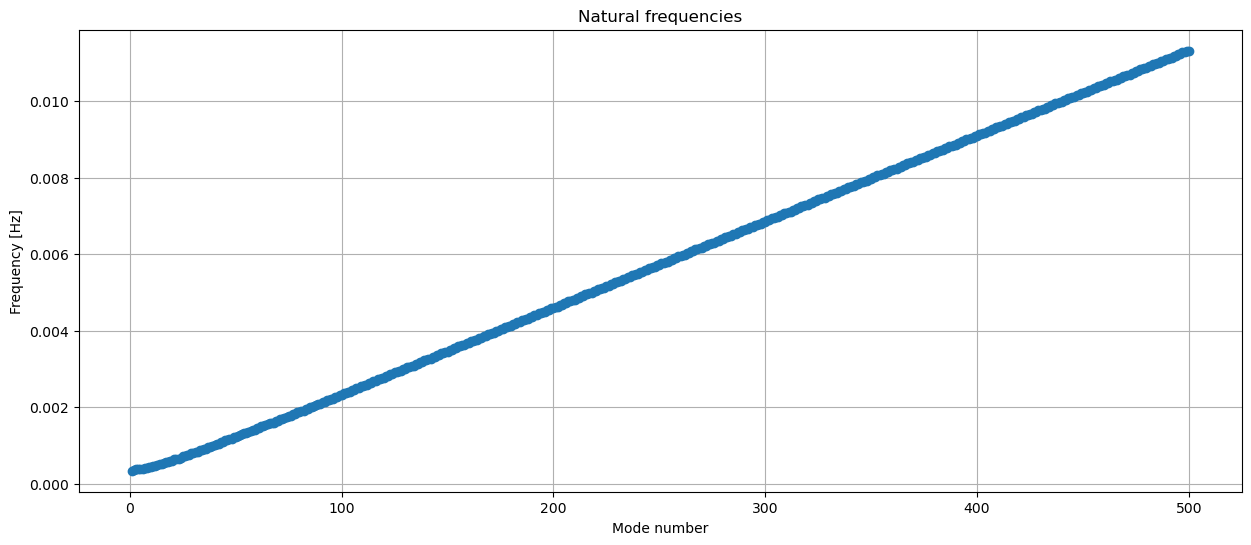

[0.00034112 0.00034761 0.00037996 0.00038652 0.00038905 0.00039055
 0.00041899 0.00042155 0.00043071 0.00044396]


In [15]:
plt.figure()
plt.plot(np.arange(1, len(f) + 1), f, "o-")
plt.xlabel("Mode number")
plt.ylabel("Frequency [Hz]")
plt.title("Natural frequencies")
plt.grid(True)
plt.show()
print(f[:10])

# Plotting Modal Shapes with corresponding Freq

In [ ]:
n_modes_available = vr.shape[1]
Phi = np.zeros((nDof, n_modes_available))
Phi[DofsF, :] = vr

def plot_mode_shapes_subplots(Phi, f, s, nModesPlot=12, direction="z"):

    dof_map = {"x": 0, "y": 1, "z": 2, "rx": 3, "ry": 4, "rz": 5,}
    local_dof = dof_map[direction]
    nModesPlot = min(nModesPlot, Phi.shape[1])
    ncols = 3
    nrows = int(np.ceil(nModesPlot / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(14, 3.5*nrows), sharex=True)
    axs = np.asarray(axs).ravel()

    for mode in range(nModesPlot):
        shape = Phi[local_dof::LDOF, mode]
        max_val = np.max(np.abs(shape))
        if max_val > 0:
            shape = shape / max_val

        axs[mode].plot(s, shape, "-o", markersize=3)
        axs[mode].axhline(0, linewidth=0.8)
        axs[mode].grid(True)
        axs[mode].set_title(f"Mode {mode+1}: f = {f[mode]:.4f} Hz")
        axs[mode].set_ylabel(direction)

    for ax in axs[nModesPlot:]:
        ax.axis("off")

    for ax in axs[-ncols:]:
        ax.set_xlabel("s [m]")

    fig.suptitle(f"Modal shapes in {direction}-direction", fontsize=14)
    plt.tight_layout()
    plt.show()

### Vertical Modal shapes

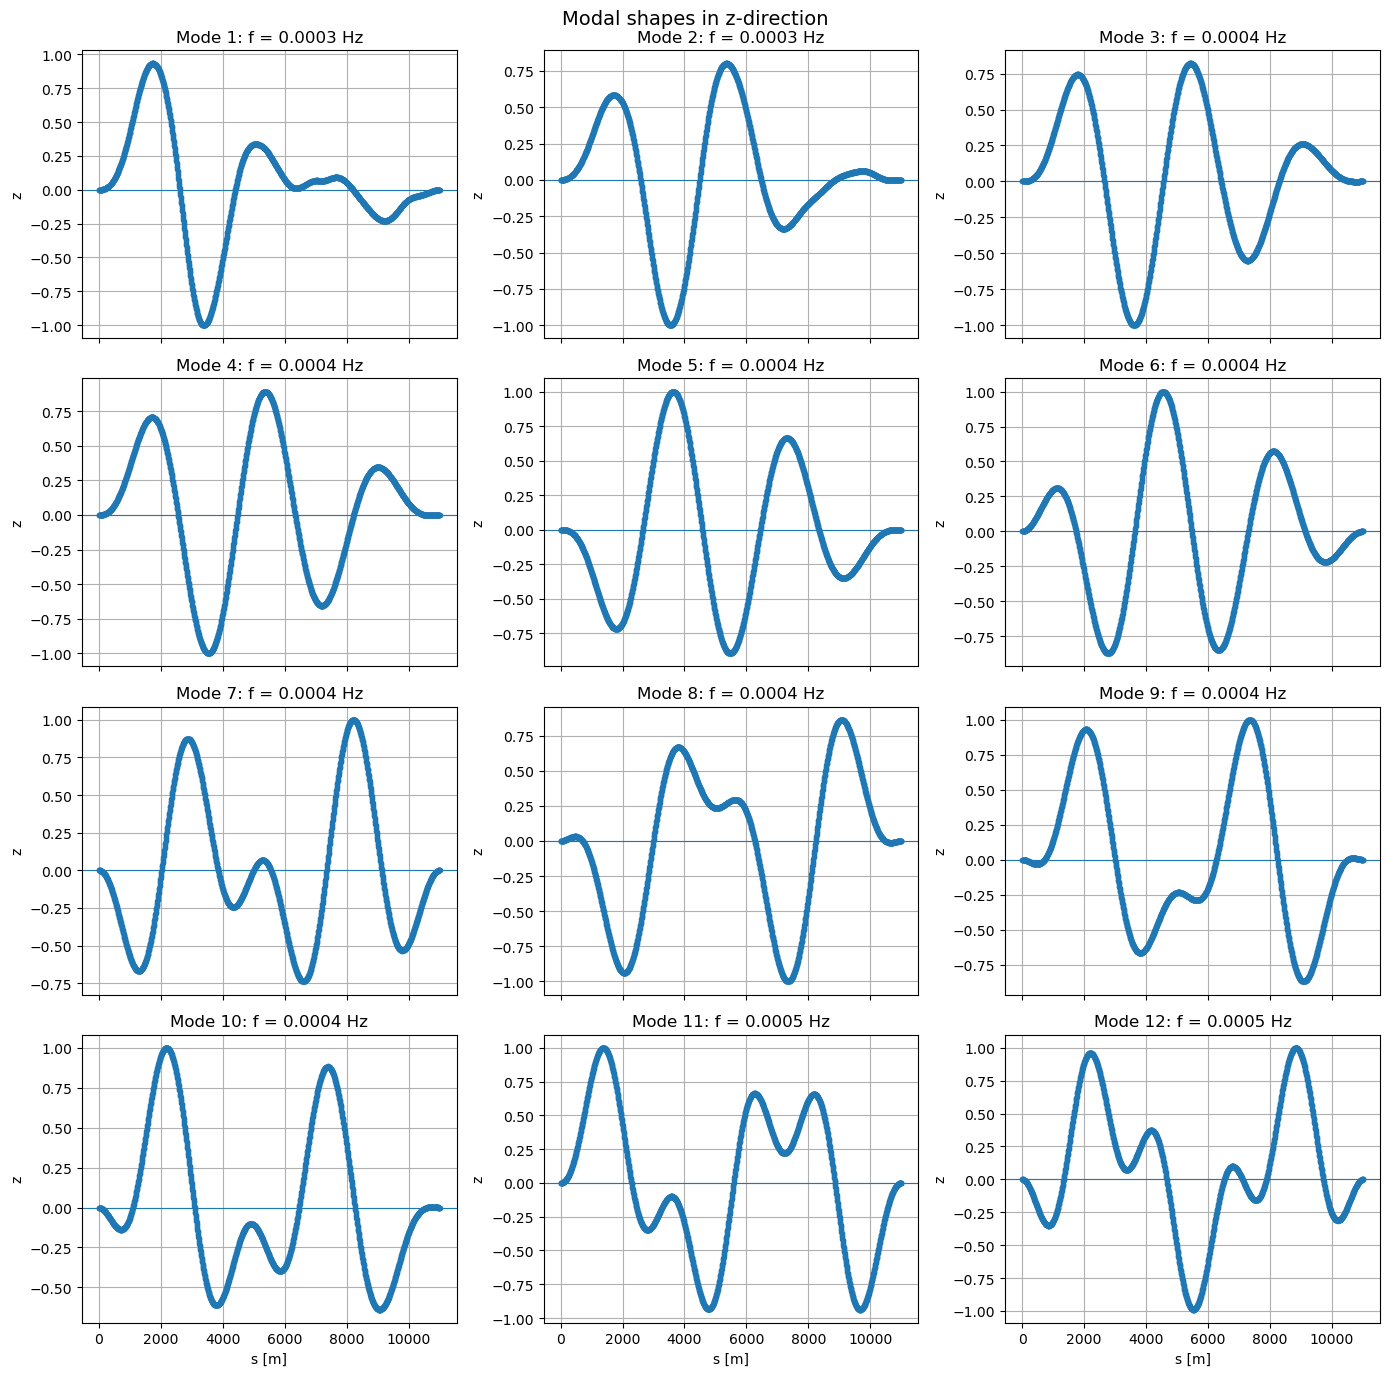

In [17]:
plot_mode_shapes_subplots(Phi, f, s, nModesPlot=12, direction="z")

### Horizontal Modal shapes

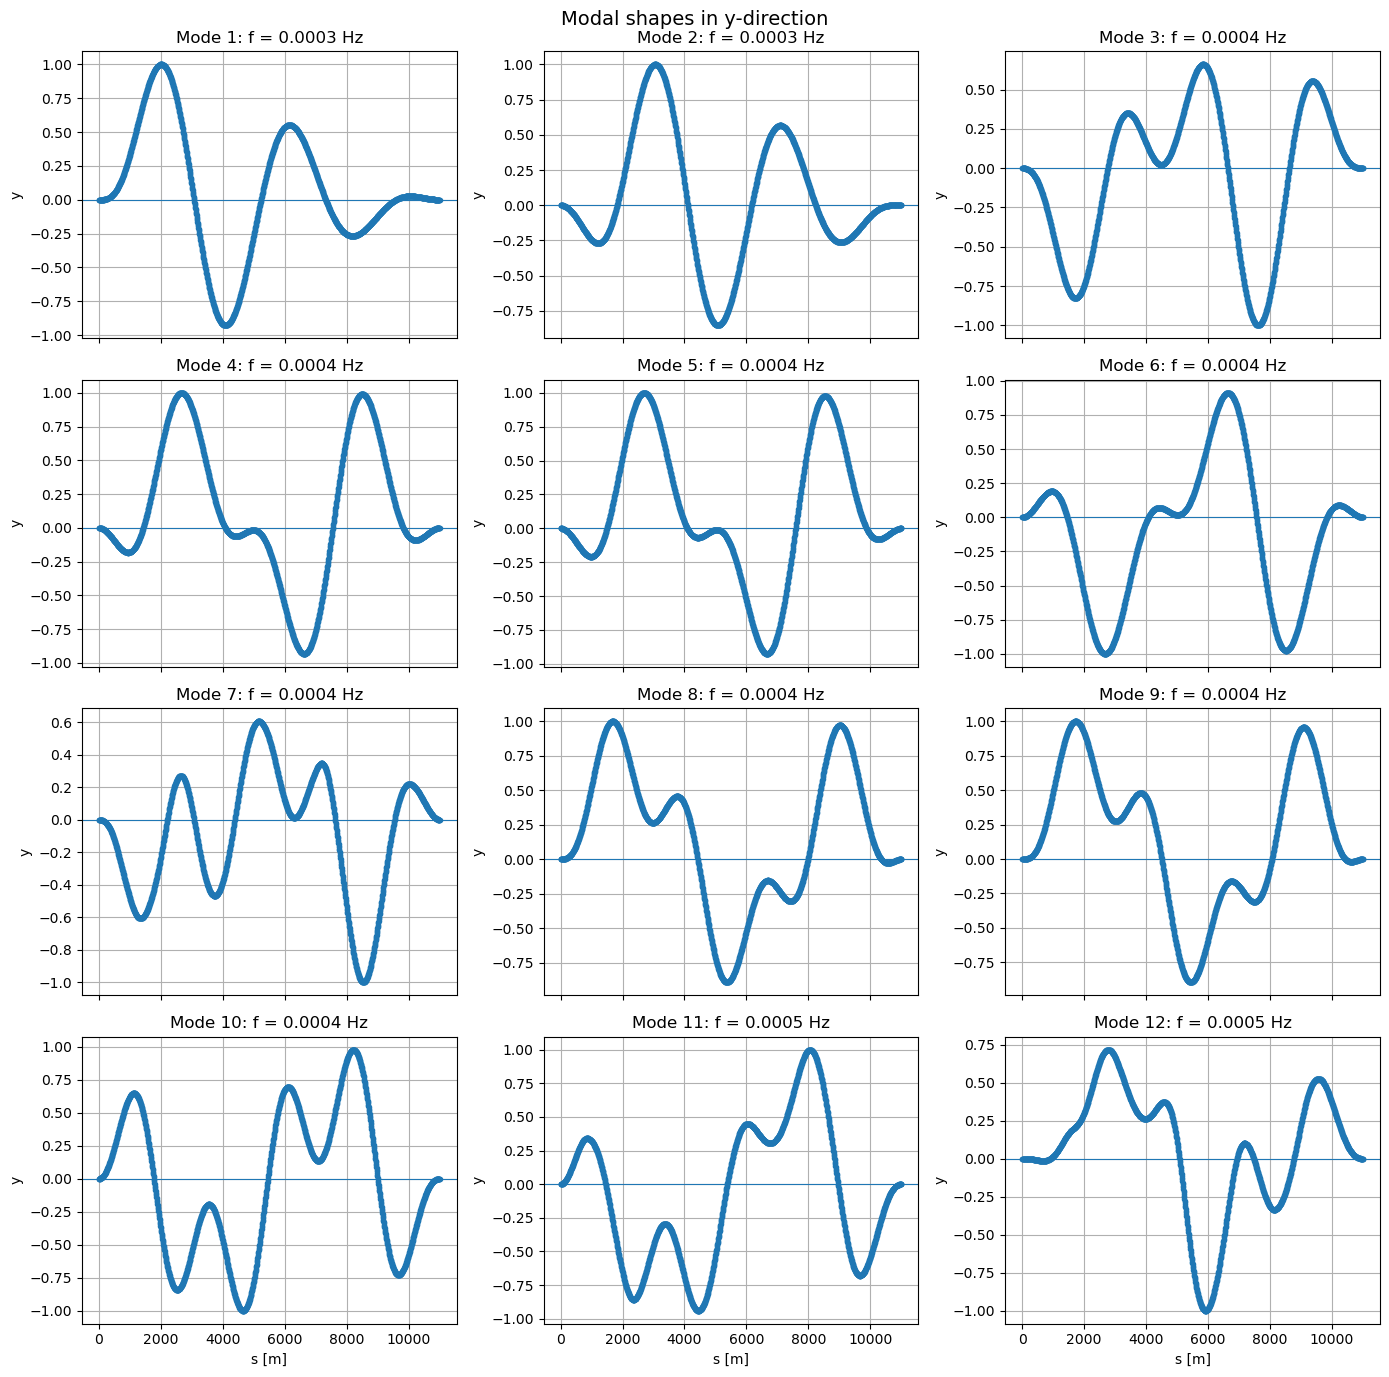

In [18]:
plot_mode_shapes_subplots(Phi, f, s, nModesPlot=12, direction="y")

### Rotational Modal shapes

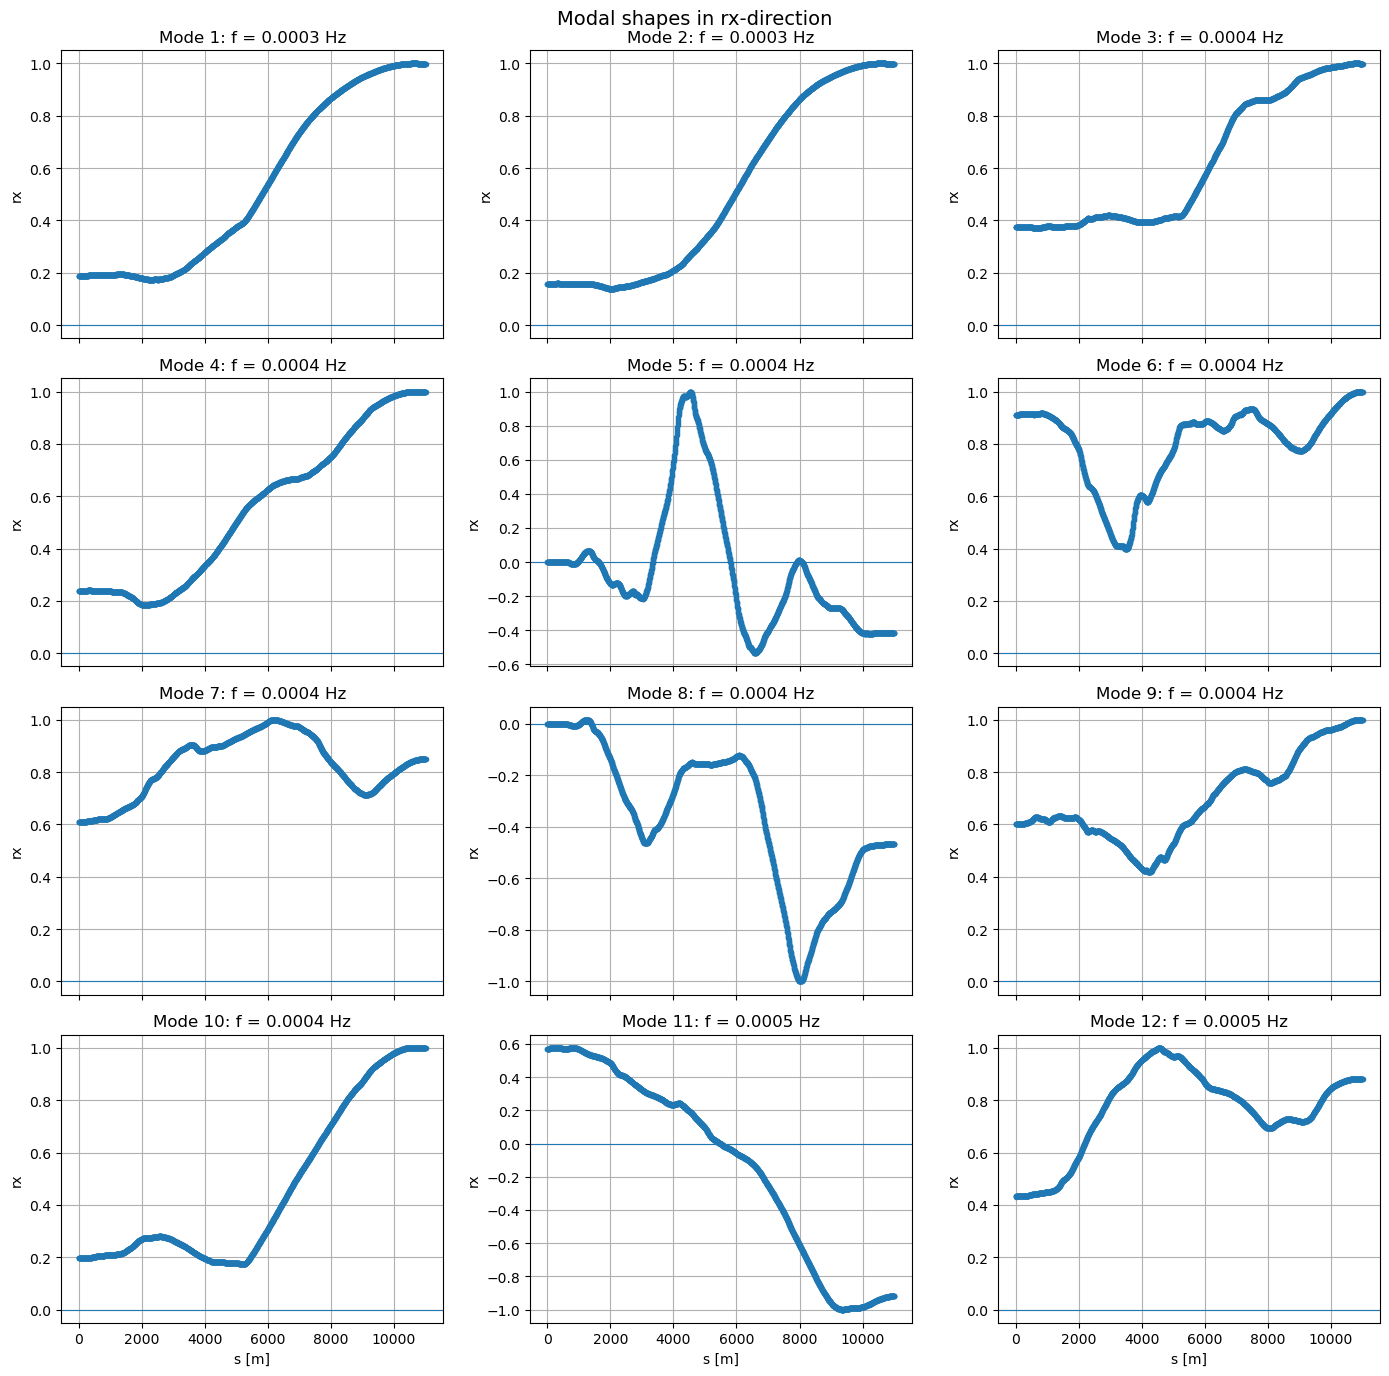

In [19]:
plot_mode_shapes_subplots(Phi, f, s, nModesPlot=12, direction="rx")

## Solving the Model Staticly

In [ ]:
qz = 250e3
mooring_restoring_force = 2900e3
element_length_factor = 25 / Le

Fz = np.zeros(nDof)

for iEle in range(nEle):
    n1 = int(Ele_tunnel[iEle][0])
    n2 = int(Ele_tunnel[iEle][1])

    Le = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))

    Fz[n1*LDOF + 2] += (qz * Le / 2) - (mooring_restoring_force / element_length_factor)
    Fz[n2*LDOF + 2] += (qz * Le / 2) - (mooring_restoring_force / element_length_factor)

F_Fz = Fz[DofsF]
u_Fz = np.linalg.solve(K_FF, F_Fz)
uz = np.zeros(nDof)
uz[DofsF] = u_Fz    

qy = 11e3 

Fy = np.zeros(nDof)

for iEle in range(nEle):
    n1 = int(Ele_tunnel[iEle][0])
    n2 = int(Ele_tunnel[iEle][1])

    Le = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))

    Fy[n1*LDOF + 1] += qy * Le / 2
    Fy[n2*LDOF + 1] += qy * Le / 2

F_Fy = Fy[DofsF]
print(F_Fy[:30])
print(np.max(np.abs(F_Fy)))

u_Fy = np.linalg.solve(K_FF, F_Fy)

uy = np.zeros(nDof)
uy[DofsF] = u_Fy


[    0.     0.     0.     0. 68750.     0.     0.     0.     0.     0.
 68750.     0.     0.     0.     0.     0. 68750.     0.     0.     0.
     0.     0. 68750.     0.     0.     0.     0.     0. 68750.     0.]
68750.0


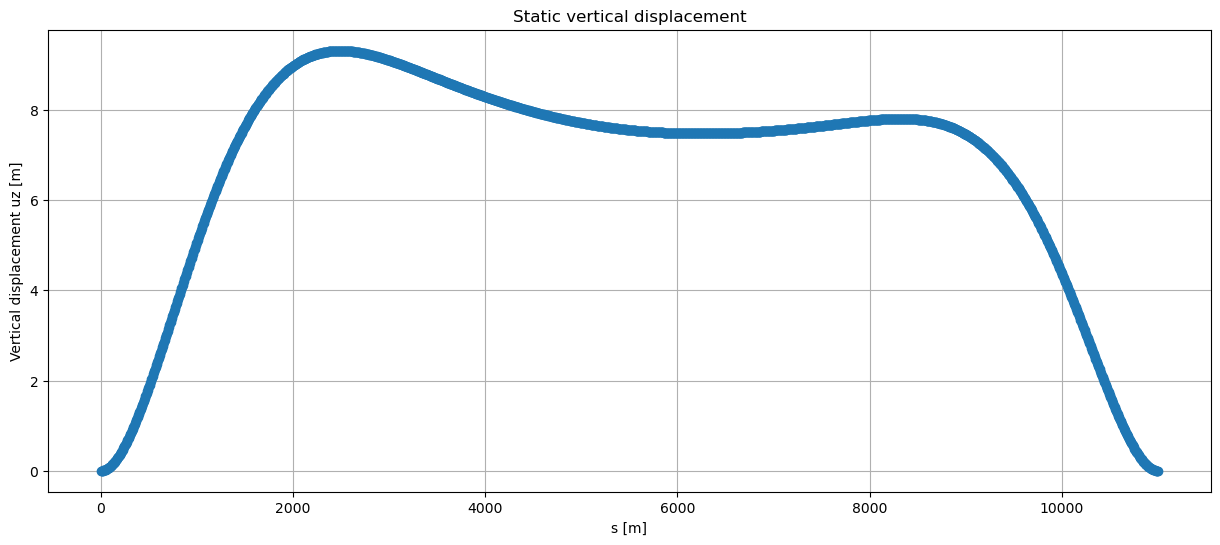

In [21]:
uz = uz[2::LDOF]

plt.figure()
plt.plot(s, uz, "-o")
plt.xlabel("s [m]")
plt.ylabel("Vertical displacement uz [m]")
plt.title("Static vertical displacement")
plt.grid()
plt.show()

## Horizontal Displacement

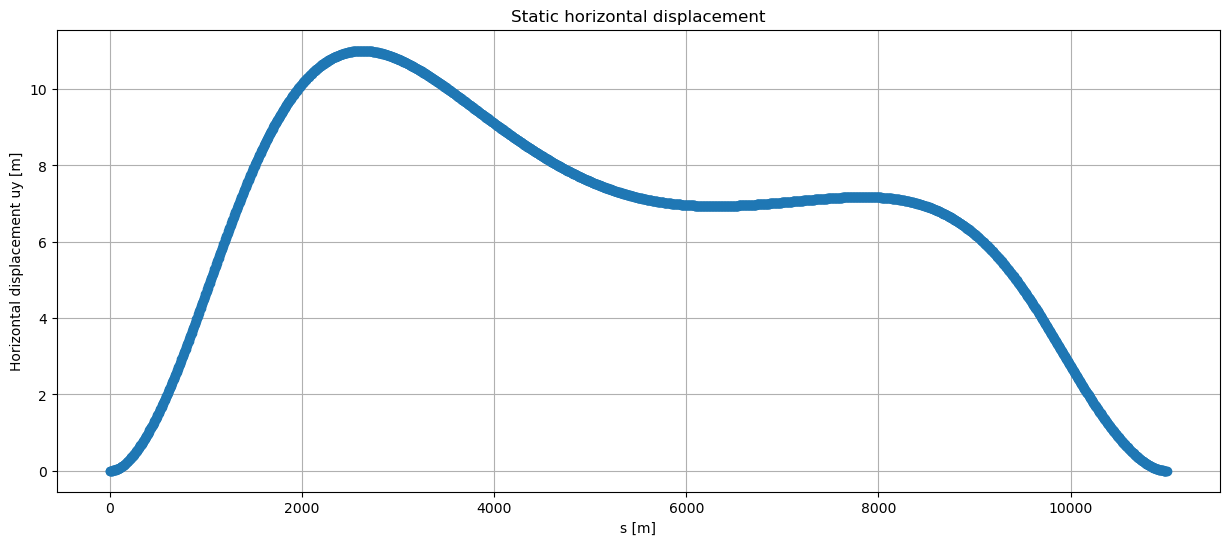

In [22]:
uy = uy[1::LDOF]

plt.figure()
plt.plot(s, uy, "-o")
plt.xlabel("s [m]")
plt.ylabel("Horizontal displacement uy [m]")
plt.title("Static horizontal displacement")
plt.grid()
plt.show()


# Dynamic modelling

## Dynamic Forcing

In [ ]:
F_static = (Fy + Fz).copy()
dt = 0.2
T_total = 500
t = np.arange(0, T_total + dt, dt)
n_steps = len(t)

Tp = 6.75
h = 44

H_wave = 2.4

n_dof = nDof

dfy = pd.read_csv("interpolated_horizontal_stiffness_data.csv")
dfz = pd.read_csv("interpolated_vertical_stiffness_data.csv")

ky_lin = LinearNDInterpolator(list(zip(dfy["water_depth_m"], dfy["u_mid_m"])), dfy["Ky_N_per_m"])
ky_near = NearestNDInterpolator(list(zip(dfy["water_depth_m"], dfy["u_mid_m"])), dfy["Ky_N_per_m"])

kz_lin = LinearNDInterpolator(list(zip(dfz["water_depth_m"], dfz["u_mid_m"])), dfz["Kz_N_per_m"])
kz_near = NearestNDInterpolator(list(zip(dfz["water_depth_m"], dfz["u_mid_m"])), dfz["Kz_N_per_m"])

def safe_interp(lin, near, h, u):
    val = lin(h, u)
    if np.isnan(val):
        val = near(h, u)
    return float(val)

depth_nodes = np.linspace(160, 275, len(mooring_nodes))

def airy_wave_properties(T, h, g=9.81):
    omega = 2*np.pi/T

    def residual(k):
        return g*k*np.tanh(k*h) - omega**2

    k0 = omega**2/g
    k = fsolve(residual, k0)[0]
    L = 2*np.pi/k
    c = omega/k

    return omega, k, L, c


omega, k, L, c = airy_wave_properties(Tp, h)


def airy_horizontal_velocity(z, x, t, H, T, h, g=9.81):
    a = H / 2
    omega, k, _, _ = airy_wave_properties(T, h, g)
    return (a * omega * np.cosh(k * (z + h)) / np.sinh(k * h) * np.cos(k*x - omega*t))


def airy_horizontal_acceleration(z, x, t, H, T, h, g=9.81):
    a = H / 2
    omega, k, _, _ = airy_wave_properties(T, h, g)
    return (a * omega**2 * np.cosh(k * (z + h)) / np.sinh(k * h) * np.sin(k*x - omega*t))


def morison_force_yz_per_length(z, x, t, H, T, h, D, Cd_y, Cm_y, Cd_z, Cm_z, rho=1027, g=9.81):

    # y
    uy = airy_horizontal_velocity(z, x, t, H, T, h, g)
    ay = airy_horizontal_acceleration(z, x, t, H, T, h, g)

    # z
    a = H / 2
    omega, k, _, _ = airy_wave_properties(T, h, g)

    uz = (a * omega * np.sinh(k * (z + h)) / np.sinh(k * h) * np.sin(k*x - omega*t))

    az = (-a * omega**2 * np.sinh(k * (z + h)) / np.sinh(k * h) * np.cos(k*x - omega*t))

    current_y = 0.8
    u_rel_y = uy + current_y

    qy = (0.5 * rho * Cd_y * D * abs(u_rel_y) * u_rel_y + rho * Cm_y * (np.pi * D**2 / 4) * ay)

    qz = (0.5 * rho * Cd_z * D * abs(uz) * uz + rho * Cm_z * (np.pi * D**2 / 4) * az)

    return qy, qz

F_time = np.zeros((n_steps, nDof))

D = 12.7
Cd_y = 0.7
Cm_y = Cm
Cd_z = 0.7
Cm_z = Cm

for n, tn in enumerate(t):

    Fdyn = np.zeros(nDof)

    for iEle in range(nEle):

        n1 = int(Ele_tunnel[iEle][0])
        n2 = int(Ele_tunnel[iEle][1])

        x1, z1 = NodeC[n1][0], NodeC[n1][2]
        x2, z2 = NodeC[n2][0], NodeC[n2][2]

        Le = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))

        qy1, qz1 = morison_force_yz_per_length(z1, x1, tn, H_wave, Tp, h, D, Cd_y, Cm_y, Cd_z, Cm_z)

        qy2, qz2 = morison_force_yz_per_length(z2, x2, tn, H_wave, Tp, h, D, Cd_y, Cm_y, Cd_z, Cm_z)

        # y
        Fdyn[n1*LDOF + 1] += Le / 6 * (2*qy1 + qy2)
        Fdyn[n2*LDOF + 1] += Le / 6 * (qy1 + 2*qy2)

        # z
        Fdyn[n1*LDOF + 2] += Le / 6 * (2*qz1 + qz2)
        Fdyn[n2*LDOF + 2] += Le / 6 * (qz1 + 2*qz2)

    F_time[n, :] = Fdyn


alpha_R = 0.01
beta_R  = 1e-4

C_FF = alpha_R * M_FF + beta_R * K_FF

beta = 1/4
gamma = 1/2

n_free = len(DofsF)

U_hist = np.zeros((n_steps, n_free))
V_hist = np.zeros((n_steps, n_free))
A_hist = np.zeros((n_steps, n_free))

u = np.zeros(n_free)
v = np.zeros(n_free)

F0 = F_static + F_time[0, :]
F0_F = F0[DofsF]

a = np.linalg.solve(M_FF, F0_F - C_FF @ v - K_FF @ u)

K_eff = (K_FF  + gamma / (beta * dt) * C_FF + 1 / (beta * dt**2) * M_FF)

F_static_F = F_static[DofsF]

u = np.linalg.solve(K_FF, F_static_F)
v = np.zeros(len(DofsF))
a = np.zeros(len(DofsF))

u_max_y = dfy["u_mid_m"].max()
u_max_z = dfz["u_mid_m"].max()

free_dof_map = {gdof: i for i, gdof in enumerate(DofsF)}

u = np.linalg.solve(K_FF, F_static_F)

for it in range(20):

    K_static = K_FF.copy()

    for i, node in enumerate(mooring_nodes):

        h_node = depth_nodes[i]

        global_dof_y = node*LDOF + 1
        global_dof_z = node*LDOF + 2

        if global_dof_y in free_dof_map:
            local_dof_y = free_dof_map[global_dof_y]
            uy_abs = np.clip(abs(u[local_dof_y]), 0.0, u_max_y)
            ky = safe_interp(ky_lin, ky_near, h_node, uy_abs)
            K_static[local_dof_y, local_dof_y] += ky

        if global_dof_z in free_dof_map:
            local_dof_z = free_dof_map[global_dof_z]
            uz_abs = np.clip(abs(u[local_dof_z]), 0.0, u_max_z)
            kz = safe_interp(kz_lin, kz_near, h_node, uz_abs)
            K_static[local_dof_z, local_dof_z] += kz

    u_new = np.linalg.solve(K_static, F_static_F)

    if np.linalg.norm(u_new - u) / np.linalg.norm(u_new) < 1e-6:
        print(f"Static mooring equilibrium converged in {it+1} iterations")
        break

    u = u_new

v = np.zeros(len(DofsF))
a = np.zeros(len(DofsF))

for n in range(n_steps):

    if np.any(np.isnan(u)):
        idx = np.where(np.isnan(u))[0][0]
        print(f"\nNaN detected in u at step {n}")
        print(f"DOF = {idx}")
        raise RuntimeError("NaN in displacement vector")

    K_nl = K_FF.copy()

    for i, node in enumerate(mooring_nodes):
        h_node = depth_nodes[i]
        global_dof_y = node*LDOF + 1
        global_dof_z = node*LDOF + 2

        if global_dof_y in free_dof_map:
            local_dof_y = free_dof_map[global_dof_y]
            uy = u[local_dof_y]
            uy_abs = np.clip(abs(uy), 0.0, u_max_y)
            ky_raw = ky_lin(h_node, uy_abs)

            if np.isnan(ky_raw):
                print("\nFIRST NaN IN KY INTERPOLATION")
                print(f"step       = {n}")
                print(f"node       = {node}")
                print(f"h_node     = {h_node}")
                print(f"uy         = {uy}")
                print(f"uy_abs     = {uy_abs}")
                raise RuntimeError("NaN from ky interpolation")

            ky = float(ky_raw)
            if np.isnan(ky):
                raise RuntimeError("ky became NaN")
            K_nl[local_dof_y, local_dof_y] += ky

        if global_dof_z in free_dof_map:
            local_dof_z = free_dof_map[global_dof_z]
            uz = u[local_dof_z]
            uz_abs = np.clip(abs(uz), 0.0, u_max_z)
            kz_raw = kz_lin(h_node, uz_abs)

            if np.isnan(kz_raw):
                print("\nFIRST NaN IN KZ INTERPOLATION")
                print(f"step       = {n}")
                print(f"node       = {node}")
                print(f"h_node     = {h_node}")
                print(f"uz         = {uz}")
                print(f"uz_abs     = {uz_abs}")
                raise RuntimeError("NaN from kz interpolation")

            kz = float(kz_raw)
            if np.isnan(kz):
                raise RuntimeError("kz became NaN")
            K_nl[local_dof_z, local_dof_z] += kz

    K_eff = (K_nl + gamma/(beta*dt)*C_FF + 1/(beta*dt**2)*M_FF)

    F_ext_F = F_static_F + F_time[n, DofsF]
    # continue with F_eff, solve u_new, update a_new/v_new

    F_eff = (F_ext_F  + M_FF @ ( 1 / (beta * dt**2) * u + 1 / (beta * dt) * v + (1 / (2 * beta) - 1) * a) + C_FF @ (gamma / (beta * dt) * u + (gamma / beta - 1) * v + dt * (gamma / (2 * beta) - 1) * a))

    u_new = np.linalg.solve(K_eff, F_eff)
    a_new = (1 / (beta * dt**2) * (u_new - u) - 1 / (beta * dt) * v - (1 / (2 * beta) - 1) * a)
    v_new = v + dt * ((1 - gamma) * a + gamma * a_new)

    U_hist[n, :] = u_new
    V_hist[n, :] = v_new
    A_hist[n, :] = a_new

    u = u_new
    v = v_new
    a = a_new



U_full = np.zeros((n_steps, nDof))
U_full[:, DofsF] = U_hist



Static mooring equilibrium converged in 4 iterations


In [24]:
print(U_full)
print(np.max(np.abs(U_full[:, DofsF])))
print(U_full.shape)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.52134584e-06 -5.45230608e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.52153628e-06 -5.47042979e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.52188437e-06 -5.52201068e-07]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.52319334e-06 -8.50635328e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.52303321e-06 -8.50578495e-07]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   1.52282976e-06 -8.50678023e-07]]
4.1025303779576285
(2501, 10566)


### Displacement of the Tunnel per time step

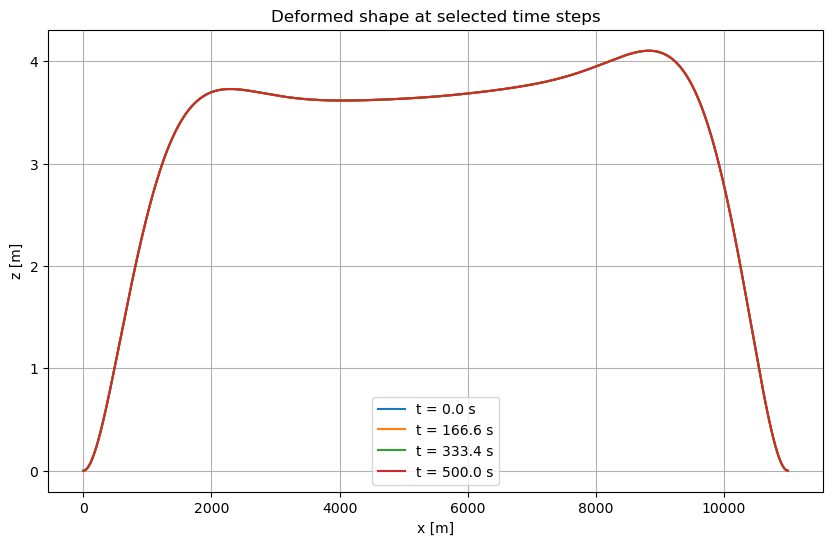

In [ ]:
plot_steps = [0, n_steps // 3, 2 * n_steps // 3, n_steps - 1]

plt.figure(figsize=(10, 6))

for n in plot_steps:
    scale = 1 
    y_def = []
    z_def = []

    for node in range(nNodes):
        y = NodeC[node][1]
        z = NodeC[node][2]

        uy = U_full[n, node*LDOF + 1]
        uz = U_full[n, node*LDOF + 2]

        y_def.append(y + scale * uy)
        z_def.append(z + scale * uz)

    plt.plot(s, z_def, label=f't = {t[n]:.1f} s')

plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.title('Deformed shape at selected time steps')
plt.grid()
plt.legend()
plt.show()

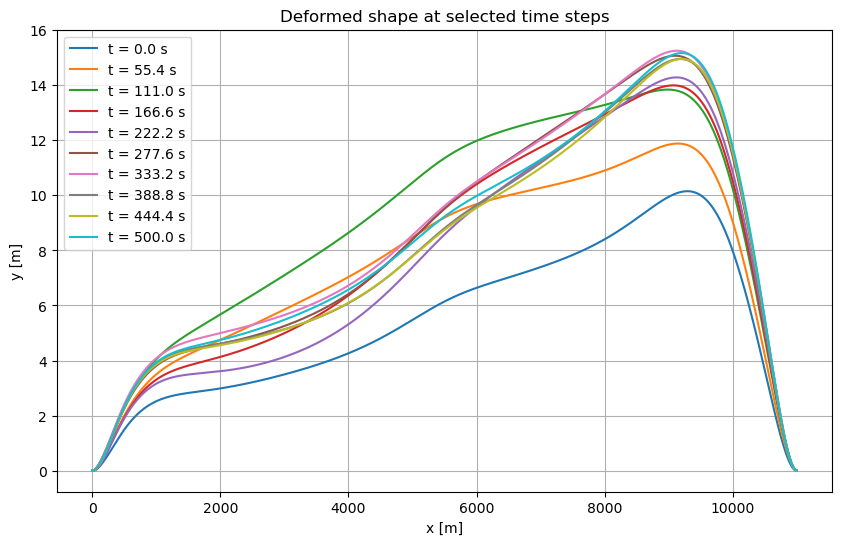

In [ ]:
plot_steps = np.linspace(0, n_steps - 1, 10, dtype=int)

plt.figure(figsize=(10, 6))

for n in plot_steps:
    scale = 10 
    y_def = []
    z_def = []

    for node in range(nNodes):
        y = NodeC[node][1]
        z = NodeC[node][2]

        uy = U_full[n, node*LDOF + 1]
        uz = U_full[n, node*LDOF + 2]

        y_def.append(y + scale * uy)
        z_def.append(z + scale * uz)

    plt.plot(s, y_def,label=f't = {t[n]:.1f} s')

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Deformed shape at selected time steps')
plt.grid()
plt.legend()
plt.show()

## Displacement of A node 

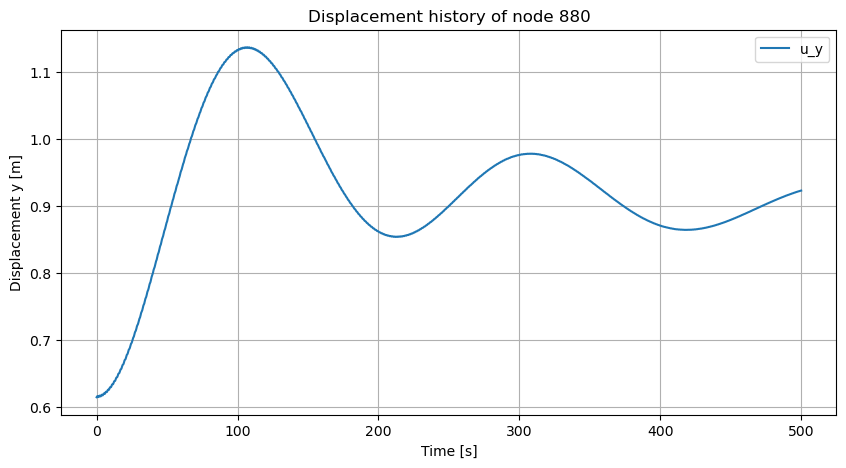

In [ ]:
node = nNodes // 2

uy_hist = U_full[:, node*LDOF + 1]
uz_hist = U_full[:, node*LDOF + 2]

plt.figure(figsize=(10,5))
plt.plot(t, uy_hist, label='u_y')
plt.xlabel('Time [s]')
plt.ylabel('Displacement y [m]')
plt.title(f'Displacement history of node {node}')
plt.grid(True)
plt.legend()
plt.show()

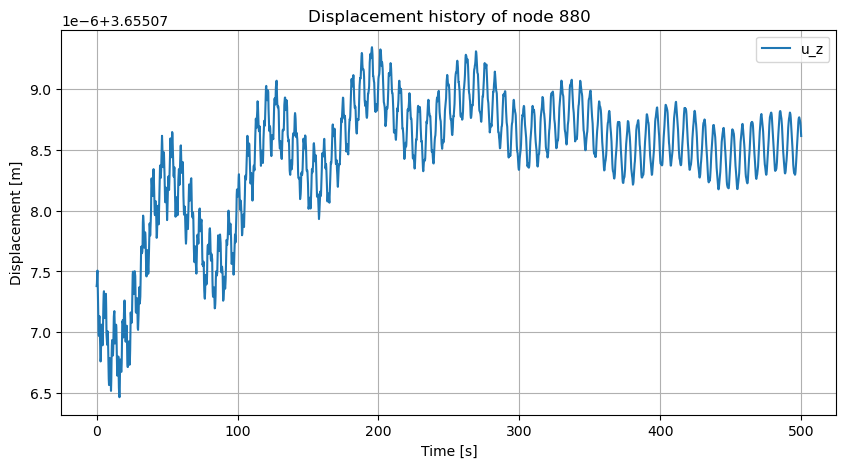

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(t, uz_hist, label='u_z')
plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.title(f'Displacement history of node {node}')
plt.grid(True)
plt.legend()
plt.show()

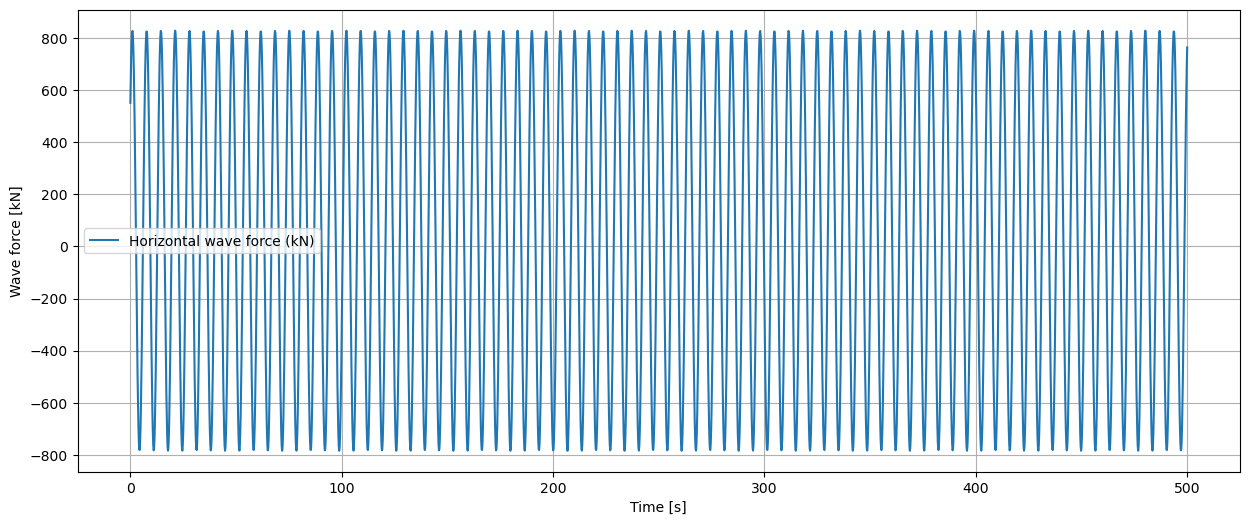

In [29]:
node_mid = len(NodeC)//2
dof = node_mid*LDOF + 1
dof2 = node_mid*LDOF + 2

plt.plot(t, F_time[:, dof]/1000, label='Horizontal wave force (kN)')
plt.xlabel("Time [s]")
plt.ylabel("Wave force [kN]")
plt.grid()
plt.legend()    
plt.show()

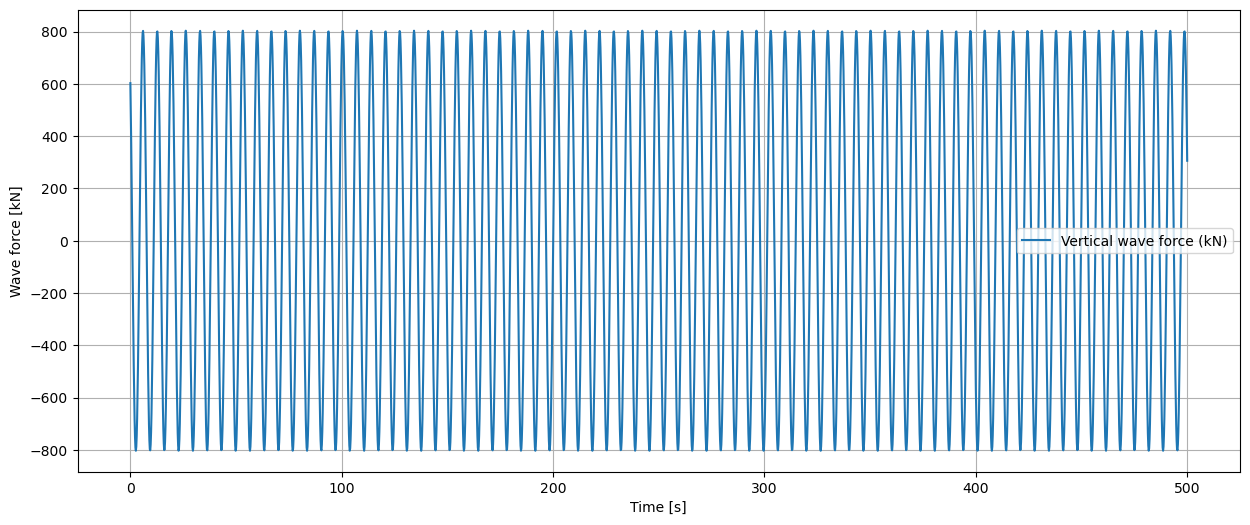

In [30]:
plt.plot(t, F_time[:, dof2]/1000, label='Vertical wave force (kN)')
plt.xlabel("Time [s]")
plt.ylabel("Wave force [kN]")
plt.grid()
plt.legend()    
plt.show()

--------------------------------------------------
The maximum frequency is 2.4990 Hz
The frequency resolution is 0.0020 Hz
The dominant frequency is 0.0000 Hz
--------------------------------------------------
The maximum amplitude is 0.0000e+00 m


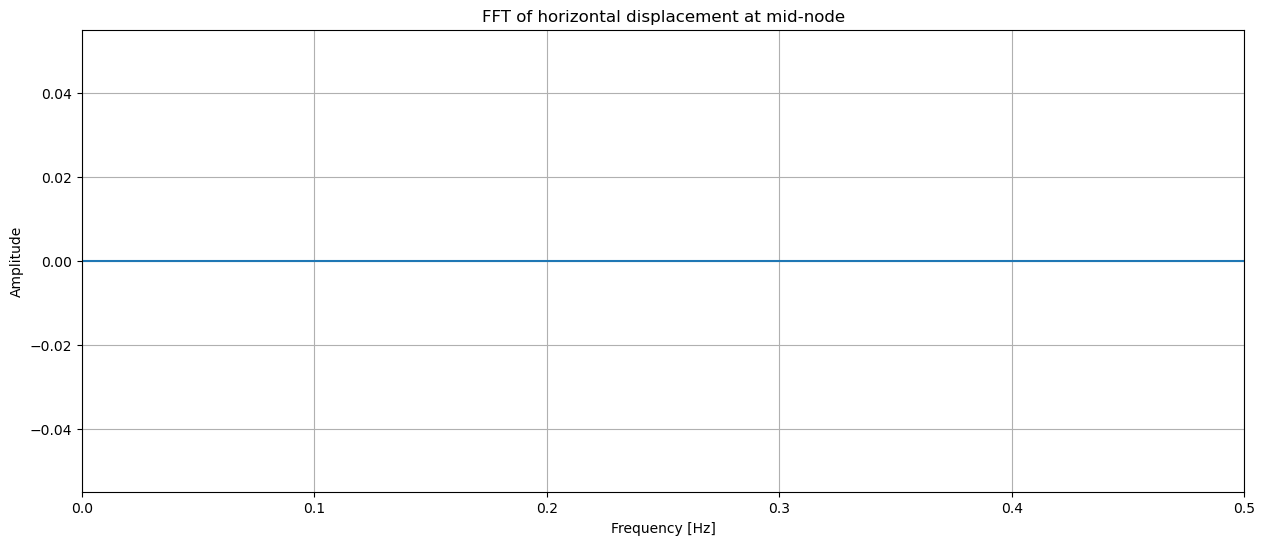

In [ ]:
sig = U_full[:, dof_y] - np.mean(U_full[:, dof_y])
freq = rfftfreq(len(sig), dt)
amp = np.abs(rfft(sig))

print("-" * 50)
print(f'The maximum frequency is {freq[-1]:.4f} Hz')
print(f'The frequency resolution is {freq[1]-freq[0]:.4f} Hz')
print(f'The dominant frequency is {freq[np.argmax(amp)]:.4f} Hz')
print("-" * 50)

print(f'The maximum amplitude is {np.max(amp):.4e} m')

plt.plot(freq, amp)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT of horizontal displacement at mid-node")
plt.xlim(0, 0.5)
plt.grid()
plt.show()

# Probabilistic 

### Function for static deformations of the tunnel

In [ ]:
from static_deformations import compute_static_deformations

N = 1000
samples = []

for i in range(N):
    qy_i = np.random.normal(11e3, 0.15 * 11e3)
    qz_i = np.random.normal(250e3, 0.15 * 250e3)
    mooring_i = np.random.normal(2900e3, 0.9 * 2900e3)

    res_i = compute_static_deformations(K_FF=K_FF,  DofsF=DofsF,  nDof=nDof, elements=Ele_tunnel,  node_coordinates=NodeC,  qy=qy_i,  qz=qz_i,  mooring_restoring_force=mooring_i)

    samples.append({ "qy": qy_i, "qz": qz_i, "mooring": mooring_i, "max_uy": np.max(np.abs(res_i.uy_nodes)), "max_uz": np.max(np.abs(res_i.uz_nodes)),})

df = pd.DataFrame(samples)
df.describe()

,qy,qz,mooring,max_uy,max_uz
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,11028.324817,251963.859366,2.919666e+06,11.034281,90.245929
std,1680.678725,37082.965207,2.649109e+06,1.681587,67.424953
min,4764.346088,137417.891269,-5.415757e+06,4.766919,0.064068
25%,9876.471757,227852.945681,1.006677e+06,9.881806,36.459681
50%,11151.463388,251220.596845,3.035353e+06,11.157487,77.782870
75%,12177.399750,277077.278138,4.634149e+06,12.183977,136.335041
max,15960.789148,367455.111412,1.118893e+07,15.969410,372.132993


In [33]:
csv_file = "detected_POT_peaks_Hs_Tp.csv"  
wave_peaks = pd.read_csv(csv_file)
Hs_values = wave_peaks["Hs_combined_m"].to_numpy(dtype=float)
Tp_values = wave_peaks["Peak_period_Tp_s"].to_numpy(dtype=float)

valid = np.isfinite(Hs_values) & np.isfinite(Tp_values)
Hs_values = Hs_values[valid]
Tp_values = Tp_values[valid]

print("Number of sea states:", len(Hs_values))
print("Hs range:", Hs_values.min(), "to", Hs_values.max())
print("Tp range:", Tp_values.min(), "to", Tp_values.max())

Number of sea states: 1473
Hs range: 1.000191569328308 to 2.41933822631836
Tp range: 3.953956604003906 to 6.749855041503906


Selected 50 random sea states
Tunnel length = 11000.00 m
Using 40 phase steps per state
Sea state 1/50 | Hs=1.989 m, Tp=6.461 s
Sea state 2/50 | Hs=1.070 m, Tp=4.598 s
Sea state 3/50 | Hs=1.061 m, Tp=5.025 s
Sea state 4/50 | Hs=1.188 m, Tp=5.128 s
Sea state 5/50 | Hs=1.587 m, Tp=5.737 s
Sea state 6/50 | Hs=1.729 m, Tp=5.820 s
Sea state 7/50 | Hs=1.155 m, Tp=5.133 s
Sea state 8/50 | Hs=1.580 m, Tp=5.204 s
Sea state 9/50 | Hs=1.128 m, Tp=4.706 s
Sea state 10/50 | Hs=1.456 m, Tp=5.498 s
Sea state 11/50 | Hs=1.067 m, Tp=4.689 s
Sea state 12/50 | Hs=1.758 m, Tp=6.162 s
Sea state 13/50 | Hs=1.295 m, Tp=4.920 s
Sea state 14/50 | Hs=1.241 m, Tp=5.102 s
Sea state 15/50 | Hs=1.241 m, Tp=5.239 s
Sea state 16/50 | Hs=1.645 m, Tp=5.953 s
Sea state 17/50 | Hs=1.177 m, Tp=4.657 s
Sea state 18/50 | Hs=1.020 m, Tp=4.410 s
Sea state 19/50 | Hs=1.290 m, Tp=5.344 s
Sea state 20/50 | Hs=1.767 m, Tp=6.178 s
Sea state 21/50 | Hs=1.182 m, Tp=4.561 s
Sea state 22/50 | Hs=1.018 m, Tp=4.779 s
Sea state 23/50 | H

,Hs,Tp,phase_index,peak_force_norm_N,qy_equiv_N_per_m,qz_equiv_N_per_m,max_ux_m,max_uy_m,max_uz_m,mid_uy_m,mid_uz_m
count,50.000000,50.000000,50.000000,5.000000e+01,50.000000,50.000000,50.0,50.000000,50.000000,50.000000,50.000000
mean,1.319063,5.199450,8.820000,2.801187e+07,68089.042272,67933.729132,0.0,1.417766,4.102511,0.858361,3.655072
std,0.257837,0.497351,13.256789,2.570105e+06,6255.368744,6232.995215,0.0,0.030489,0.000107,0.018459,0.000105
min,1.006717,4.410011,0.000000,2.402492e+07,58375.500911,58260.764644,0.0,1.377187,4.101878,0.833794,3.654800
25%,1.133316,4.764137,1.000000,2.620117e+07,63678.998062,63538.427642,0.0,1.395237,4.102528,0.844722,3.655077
50%,1.241308,5.132179,3.000000,2.792637e+07,67872.942577,67734.287960,0.0,1.413544,4.102529,0.855806,3.655079
75%,1.466707,5.438210,6.000000,2.923426e+07,71023.372184,70924.878096,0.0,1.440017,4.102531,0.871834,3.655079
max,1.989021,6.460793,38.000000,3.619105e+07,87979.017395,87766.916066,0.0,1.497264,4.102697,0.906490,3.655659


,Hs,Tp,phase_index,peak_force_norm_N,qy_equiv_N_per_m,qz_equiv_N_per_m,max_ux_m,max_uy_m,max_uz_m,mid_uy_m,mid_uz_m
0,1.989021,6.460793,3,3.026601e+07,73589.399899,73373.215754,0.0,1.479273,4.102534,0.895605,3.655081
1,1.070452,4.598488,36,2.698464e+07,65582.905086,65446.430251,0.0,1.397125,4.102531,0.845864,3.655079
2,1.061213,5.025246,6,2.402492e+07,58375.500911,58260.764644,0.0,1.377187,4.102529,0.833794,3.655079
3,1.187796,5.127785,5,2.615719e+07,63557.601148,63435.158098,0.0,1.396022,4.102529,0.845196,3.655078
4,1.586964,5.736671,37,2.950588e+07,71727.504516,71564.866668,0.0,1.443297,4.102528,0.873820,3.655077


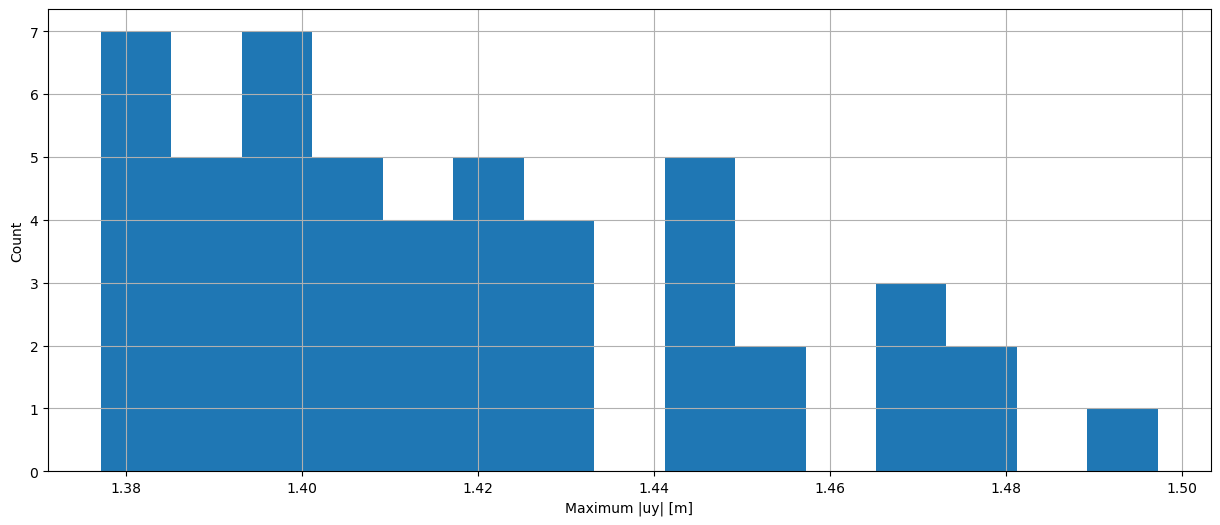

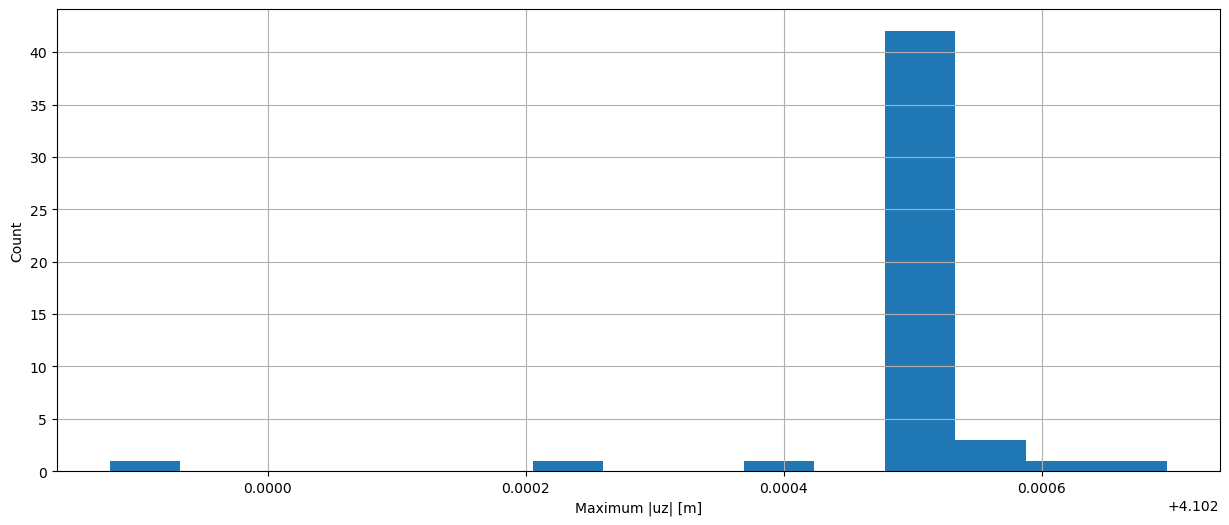

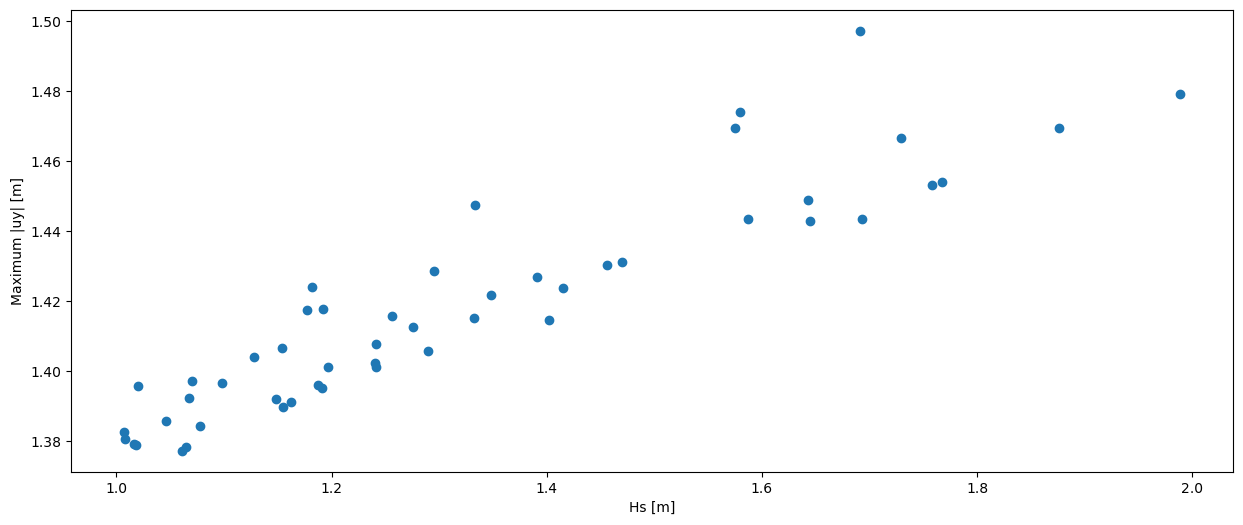

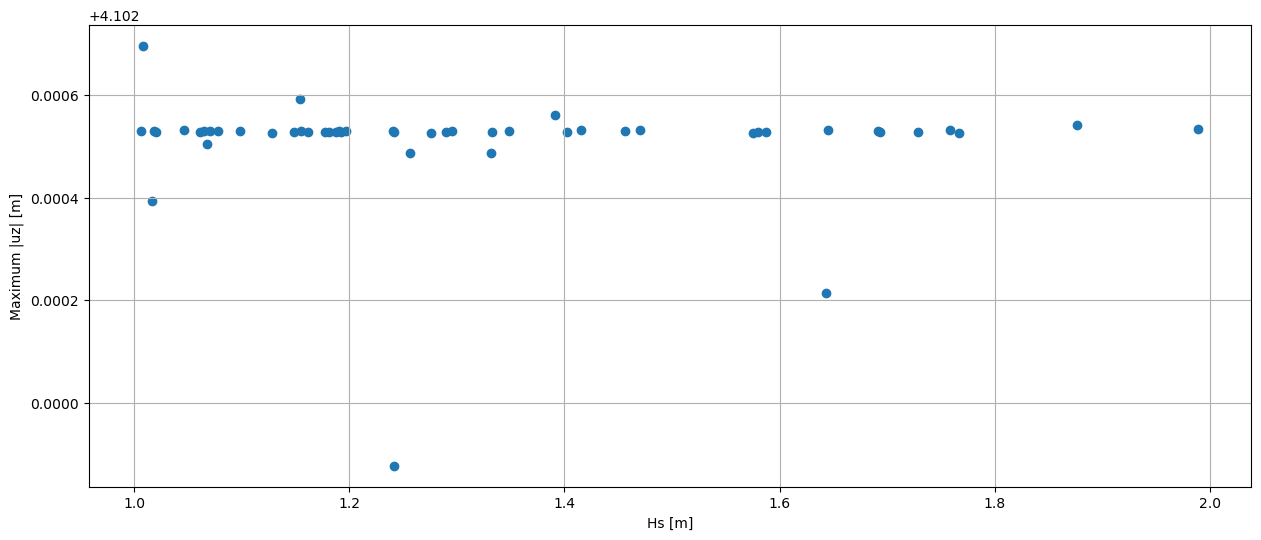

In [ ]:
Hs_values = np.asarray(Hs_values, dtype=float)
Tp_values = np.asarray(Tp_values, dtype=float)

valid = np.isfinite(Hs_values) & np.isfinite(Tp_values)
Hs_values = Hs_values[valid]
Tp_values = Tp_values[valid]

assert len(Hs_values) == len(Tp_values), "Hs_values and Tp_values must have the same length"

N_sample = 50
random_seed = 22

rng = np.random.default_rng(seed=random_seed)

idx = rng.choice(len(Hs_values), size=min(N_sample, len(Hs_values)), replace=False)

Hs_values = Hs_values[idx]
Tp_values = Tp_values[idx]
N_mc = len(Hs_values)

print(f"Selected {N_mc} random sea states")

n_phase_steps = 40 

D = 12.7
Cd_y = 0.7
Cm_y = Cm
Cd_z = 0.7
Cm_z = Cm

h = 44

element_data = []

tunnel_length = 0.0

for iEle in range(nEle):
    n1 = int(Ele_tunnel[iEle][0])
    n2 = int(Ele_tunnel[iEle][1])
    x1, z1 = NodeC[n1][0], NodeC[n1][2]
    x2, z2 = NodeC[n2][0], NodeC[n2][2]
    Le_i = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))
    tunnel_length += Le_i
    element_data.append((n1, n2, x1, z1, x2, z2, Le_i))

print(f"Tunnel length = {tunnel_length:.2f} m")
print(f"Using {n_phase_steps} phase steps per state")

K_lu = lu_factor(K_static)

def solve_static_fast(F_total):
    F_F = F_total[DofsF]
    u_F = lu_solve(K_lu, F_F)
    u_full = np.zeros(nDof)
    u_full[DofsF] = u_F
    ux_nodes = u_full[0::LDOF]
    uy_nodes = u_full[1::LDOF]
    uz_nodes = u_full[2::LDOF]

    return u_full, ux_nodes, uy_nodes, uz_nodes


def assemble_peak_wave_force_fast(H_wave, Tp):
    t_local = np.linspace(0.0, Tp, n_phase_steps)
    best_norm = -np.inf
    best_force = None
    best_phase = None

    for phase_id, tn in enumerate(t_local):

        Fdyn = np.zeros(nDof)

        for n1, n2, x1, z1, x2, z2, Le_i in element_data:
            qy1, qz1 = morison_force_yz_per_length(z1, x1, tn, H_wave, Tp, h, D, Cd_y, Cm_y, Cd_z, Cm_z)
            qy2, qz2 = morison_force_yz_per_length(z2, x2, tn, H_wave, Tp, h, D, Cd_y, Cm_y, Cd_z, Cm_z)

            # Equivalent nodal wave forces in y-direction
            Fdyn[n1*LDOF + 1] += Le_i / 6.0 * (2.0*qy1 + qy2)
            Fdyn[n2*LDOF + 1] += Le_i / 6.0 * (qy1 + 2.0*qy2)

            # Equivalent nodal wave forces in z-direction
            Fdyn[n1*LDOF + 2] += Le_i / 6.0 * (2.0*qz1 + qz2)
            Fdyn[n2*LDOF + 2] += Le_i / 6.0 * (qz1 + 2.0*qz2)

        current_norm = np.linalg.norm(Fdyn)

        if current_norm > best_norm:
            best_norm = current_norm
            best_force = Fdyn.copy()
            best_phase = phase_id

    return best_force, best_phase, best_norm

mc_results = []

for i, (H_wave, Tp) in enumerate(zip(Hs_values, Tp_values)):

    print(f"Sea state {i+1}/{N_mc} | Hs={H_wave:.3f} m, Tp={Tp:.3f} s")

    F_wave_peak, idx_peak, peak_force_norm = assemble_peak_wave_force_fast(H_wave=H_wave, Tp=Tp)
    F_total = F_static + F_wave_peak
    u_full, ux_nodes, uy_nodes, uz_nodes = solve_static_fast(F_total)

    total_Fy_wave = np.sum(np.abs(F_wave_peak[1::LDOF]))
    total_Fz_wave = np.sum(np.abs(F_wave_peak[2::LDOF]))

    qy_equiv = total_Fy_wave / tunnel_length
    qz_equiv = total_Fz_wave / tunnel_length

    mc_results.append({
        "Hs": H_wave,
        "Tp": Tp,
        "phase_index": idx_peak,
        "peak_force_norm_N": peak_force_norm,
        "qy_equiv_N_per_m": qy_equiv,
        "qz_equiv_N_per_m": qz_equiv,
        "max_ux_m": np.max(np.abs(ux_nodes)),
        "max_uy_m": np.max(np.abs(uy_nodes)),
        "max_uz_m": np.max(np.abs(uz_nodes)),
        "mid_uy_m": uy_nodes[len(uy_nodes)//2],
        "mid_uz_m": uz_nodes[len(uz_nodes)//2],
    })

df_mc = pd.DataFrame(mc_results)

print("Monte Carlo complete")
display(df_mc.describe())
display(df_mc.head())

plt.hist(df_mc["max_uy_m"], bins=15)
plt.xlabel("Maximum |uy| [m]")
plt.ylabel("Count")
plt.grid()

plt.figure()
plt.hist(df_mc["max_uz_m"], bins=15)
plt.xlabel("Maximum |uz| [m]")
plt.ylabel("Count")
plt.grid()


plt.figure()
plt.scatter(df_mc["Hs"], df_mc["max_uy_m"])
plt.xlabel("Hs [m]")
plt.ylabel("Maximum |uy| [m]")


plt.figure()
plt.scatter(df_mc["Hs"], df_mc["max_uz_m"])
plt.xlabel("Hs [m]")
plt.ylabel("Maximum |uz| [m]")
plt.grid()



In [35]:
print(E)

39000000000.0


# Obtain stresses using shape functions

In [ ]:
def beam_bending_moment_from_shape_functions(u_full, EI, E, direction="y", n_points=2):
    results = []

    for iEle in range(nEle):
        n1 = int(Ele_tunnel[iEle][0])
        n2 = int(Ele_tunnel[iEle][1])
        x1 = NodeC[n1][0]
        Le = np.linalg.norm(np.asarray(NodeC[n2]) - np.asarray(NodeC[n1]))

        if direction == "y":

            d = np.array([
                u_full[n1*LDOF + 1],  # uy1
                u_full[n1*LDOF + 5],  # rz1
                u_full[n2*LDOF + 1],  # uy2
                u_full[n2*LDOF + 5],  # rz2
            ])

        elif direction == "z":

            d = np.array([
                u_full[n1*LDOF + 2],   # uz1
               -u_full[n1*LDOF + 4],   # ry1
                u_full[n2*LDOF + 2],   # uz2
               -u_full[n2*LDOF + 4],   # ry2
            ])

        else:
            raise ValueError("direction must be 'y' or 'z'")

        xi_values = np.linspace(0, Le, n_points + 2)[1:-1]

        for xi in xi_values:

            B_curv = np.array([-6/Le**2 + 12*xi/Le**3, -4/Le    +  6*xi/Le**2,  6/Le**2 - 12*xi/Le**3, -2/Le    +  6*xi/Le**2,])
            curvature = B_curv @ d
            M = EI * curvature
            results.append([iEle, xi, x1 + xi, curvature, M])

    return pd.DataFrame(results, columns=["element", "x_local", "x_global", "curvature", "M"])

Moment points: 3520


In [ ]:
moment_y = beam_bending_moment_from_shape_functions(u_full=u_full, EI=Beam_EIy, E=E, direction="y", n_points=10)
moment_z = beam_bending_moment_from_shape_functions(u_full=u_full, EI=Beam_EIz, E=E, direction="z", n_points=10)

moment_y.head(5)


,element,x_local,x_global,curvature,M
0,0,0.568182,0.568182,0.000004,1.123582e+09
1,0,1.136364,1.136364,0.000004,1.120015e+09
2,0,1.704545,1.704545,0.000004,1.116447e+09
3,0,2.272727,2.272727,0.000004,1.112880e+09
4,0,2.840909,2.840909,0.000004,1.109312e+09


In [191]:
moment_z.head(5)

,element,x_local,x_global,curvature,M
0,0,0.568182,0.568182,0.000014,3.909236e+09
1,0,1.136364,1.136364,0.000014,3.902724e+09
2,0,1.704545,1.704545,0.000014,3.896212e+09
3,0,2.272727,2.272727,0.000014,3.889700e+09
4,0,2.840909,2.840909,0.000014,3.883188e+09


# Stresses

In [ ]:
def stress_from_bending_moment(M, c, EI, E):
    I = EI / E
    return M * c  / I


c = 0.5 * D =

sigma_y_bending = stress_from_bending_moment(moment_y["M"], c, Beam_EIy, E)
sigma_z_bending = stress_from_bending_moment(moment_z["M"], c, Beam_EIz, E)

print(f"Max bending stress in y-direction: {np.max(sigma_y_bending/1e6):.2f} MPa")
print(f"Max bending stress in z-direction: {np.max(sigma_z_bending/1e6):.2f} MPa")
print(f"Min bending stress in z-direction: {np.min(sigma_z_bending/1e6):.2f} MPa")

Max bending stress in y-direction: 1.84 MPa
Max bending stress in z-direction: 3.76 MPa
Min bending stress in z-direction: -0.79 MPa


In [ ]:
def axial_force_from_shape_functions(u_full, EA):
    rows = []

    for iEle in range(nEle):
        n1 = int(Ele_tunnel[iEle][0])
        n2 = int(Ele_tunnel[iEle][1])

        x1 = np.asarray(NodeC[n1], dtype=float)
        x2 = np.asarray(NodeC[n2], dtype=float)

        dx = x2 - x1
        Le = np.linalg.norm(dx)
        e = dx / Le  
        u1 = np.array([u_full[n1*LDOF + 0], u_full[n1*LDOF + 1], u_full[n1*LDOF + 2]])
        u2 = np.array([u_full[n2*LDOF + 0], u_full[n2*LDOF + 1], u_full[n2*LDOF + 2]])
        axial_strain = np.dot(u2 - u1, e) / Le
        N = EA * axial_strain

        rows.append({"element": iEle, "axial_strain": axial_strain, "N": N})

    return pd.DataFrame(rows)

axial_forces = axial_force_from_shape_functions(u_full, EA=Beam_EA)



# Combined stresses

In [ ]:
def circular_stress_from_AI(N, My, Mz, A, I, D):
    c = D / 2
    M_R = np.sqrt(My**2 + Mz**2)
    sigma_max = N / A + 9 * M_R * c / I
    sigma_min = N / A - 9 * M_R * c / I

    return sigma_max, sigma_min


stress_df = moment_y.copy()

stress_df["N"] = np.repeat(axial_forces["N"].values, 10)
stress_df["My"] = moment_y["M"].values
stress_df["Mz"] = moment_z["M"].values

A = Beam_EA / E
I = Beam_EIy / E 

stress_df[["sigma_max", "sigma_min"]] = stress_df.apply(lambda r: circular_stress_from_AI(r["N"], r["My"], r["Mz"], A, I, D), axis=1, result_type="expand")

stress_df["sigma_comp"] = -stress_df["sigma_min"]

print("Max tensile stress =", stress_df["sigma_max"].max() / 1e6, "MPa")
print("Max compressive stress =", stress_df["sigma_comp"].max() / 1e6, "MPa")
print("Min stress value =", stress_df["sigma_min"].min() / 1e6, "MPa")
print(len(stress_df))

Max tensile stress = 37.668178288799965 MPa
Max compressive stress = 37.668178288799965 MPa
Min stress value = -37.668178288799965 MPa
17600


In [ ]:
print("c =", c)
print("E =", E)
print(f"Beam_EIy =", f"{Beam_EIy:.2f}", "N*m^2")
print(f"Beam_EIz =", f"{Beam_EIz:.2f}", "N*m^2")
print(f"Iy =", f"{Beam_EIy / E:.2f}", "m^4")
print(f"Iz =", f"{Beam_EIz / E:.2f}", "m^4")
print("max My =", np.max(np.abs(moment_y["M"])))
print("max Mz =", np.max(np.abs(moment_z["M"])))
print("max curvature y =", moment_y["curvature"].abs().max())
print("max curvature z =", moment_z["curvature"].abs().max())

c = 6.35
E = 39000000000.0
Beam_EIy = 282393054125000.00 N*m^2
Beam_EIz = 282394131500000.00 N*m^2
Iy = 7240.85 m^4
Iz = 7240.88 m^4
max My = 2097271282.7754357
max Mz = 4287004006.3118505
max curvature y = 7.4267806949921935e-06
max curvature z = 1.518092455937545e-05


# Limit state function

In [197]:
def limit_state_function(stress):
    concrete_strength_values = np.random.normal(loc=45e6, scale=5e6, size=len(stress))
    g = concrete_strength_values - stress
    fig, ax = plt.subplots(3, 1)
    plt.tight_layout(pad = 3.0)

    ax[0].hist(concrete_strength_values/1e6, bins=20, alpha=0.7)
    ax[0].set_title("Concrete strength distribution (MPa)")
    ax[0].set_xlabel("Strength [MPa]")
    ax[0].set_ylabel("Frequency")


    ax[1].hist(stress/1e6, bins=20, alpha=0.7)
    ax[1].set_title("Structural stress distribution (MPa)")
    ax[1].set_xlabel("Stress [MPa]")
    ax[1].set_ylabel("Frequency")

    ax[2].hist(g / 1e6, bins=20, alpha=0.7)
    ax[2].axvline(0, color='red', linestyle='--', label='Failure threshold')
    ax[2].legend()
    ax[2].set_title("Margin of safety distribution (MPa)")
    ax[2].set_xlabel("Margin of safety [MPa]")
    ax[2].set_ylabel("Frequency")

    print(f'The probability of failure is {np.sum(g < 0) / len(g)}')
    print(f'amount of times g < 0 :{np.sum(g<0)}')
    return concrete_strength_values - stress


The probability of failure is 5.681818181818182e-05
amount of times g < 0 :1


0        7.891527e+06
1        1.645370e+07
2        8.180691e+06
3        1.017992e+07
4        1.482750e+07
             ...     
17595    3.175214e+06
17596    1.560087e+06
17597    4.895156e+06
17598    5.154874e+06
17599    5.766704e+06
Name: sigma_max, Length: 17600, dtype: float64

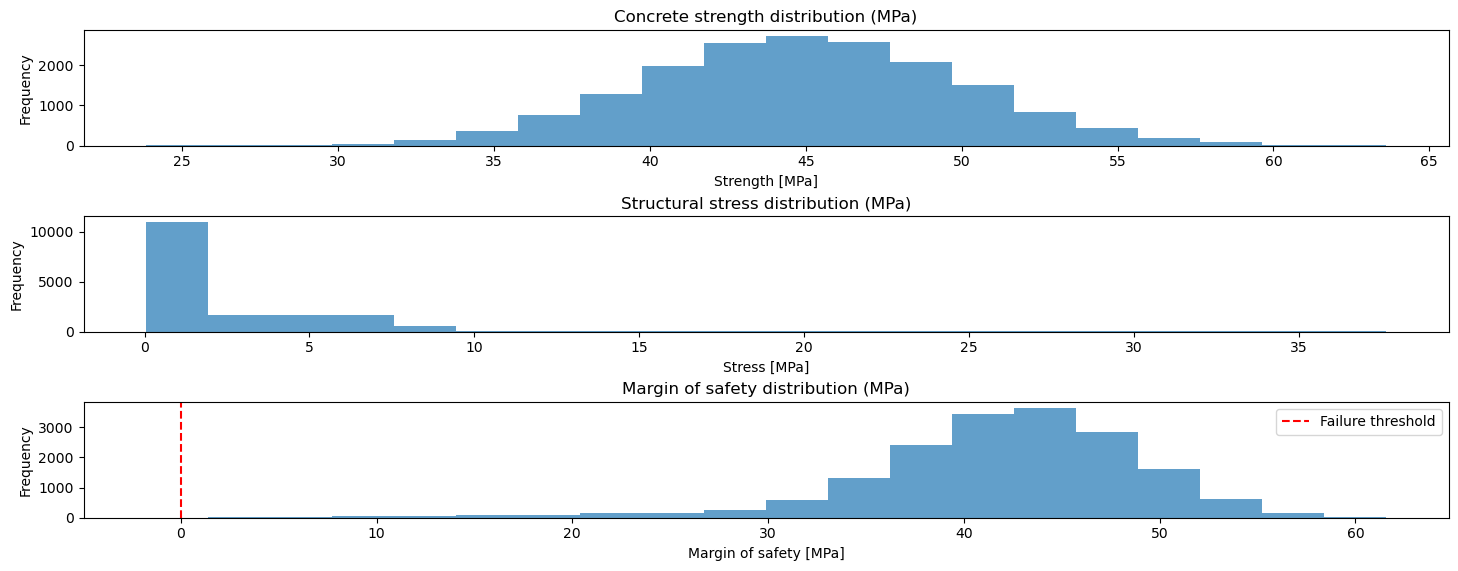

In [198]:
limit_state_function(stress_df["sigma_max"])